
# Análisis de inversión de perturbación — PolyF3BG15742708

Este notebook reproduce el análisis de las tres curvas de la cadena de perturbación:

1. **seed inicial hardcoded** de la primera inversión;
2. **best de la primera corrida** `15824988`;
3. **best de la segunda corrida / restart** `15868514`.

La cadena es consistente con PolyF3:

```text
separación PolyF3 → background físico PolyF3 BBO-2 best 15742708 → inversión de perturbación F3+nexp
```

El objetivo del notebook es auditar métricas, parámetros y residuales contra los datos reales corregidos usados como target de la inversión.



## 1. Paquetes y configuración general

El notebook asume que los dos HDF5 de resultados están en el mismo directorio desde donde se ejecuta el notebook. También se pueden redefinir mediante variables de entorno.


In [1]:

using HDF5
using Dates
using Statistics
using DataFrames
using Printf
using CairoMakie

CairoMakie.activate!()

const FIRST_H5 = get(
    ENV,
    "FIRST_PERT_H5",
    "new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_rel10_results_15824988.h5",
)

const SECOND_H5 = get(
    ENV,
    "SECOND_PERT_H5",
    "new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_restart_from_15824988_rel10_results_15868514.h5",
)

@assert isfile(FIRST_H5) "No encuentro FIRST_H5 = $FIRST_H5"
@assert isfile(SECOND_H5) "No encuentro SECOND_H5 = $SECOND_H5"

println("FIRST_H5  = ", FIRST_H5)
println("SECOND_H5 = ", SECOND_H5)


FIRST_H5  = new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_rel10_results_15824988.h5
SECOND_H5 = new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_restart_from_15824988_rel10_results_15868514.h5



## 2. Funciones auxiliares


In [2]:

read1(path::AbstractString, dset::AbstractString) = h5read(path, dset)[1]

function unix_to_datetime(t)
    return DateTime(1970, 1, 1) + Millisecond(round(Int, 1000 * Float64(t)))
end

function dt_minutes_from_start(dt::Vector{DateTime})
    t0 = dt[1]
    return [Dates.value(d - t0) / 60000 for d in dt]
end

function read_metrics(path::AbstractString, group::AbstractString)
    return (
        chi2_A     = read1(path, "$group/metrics/chi2_A"),
        chi2_phi   = read1(path, "$group/metrics/chi2_phi"),
        chi2_total = read1(path, "$group/metrics/chi2_total"),
        rmse_A     = read1(path, "$group/metrics/rmse_A"),
        rmse_phi   = read1(path, "$group/metrics/rmse_phi"),
    )
end

function metric_label(name::AbstractString, m)
    return @sprintf(
        "%s | χ²A=%.4f, χ²ϕ=%.4f, χ²tot=%.4f, RMSEA=%.3f dB, RMSEϕ=%.2f°",
        name,
        m.chi2_A,
        m.chi2_phi,
        m.chi2_total,
        m.rmse_A,
        m.rmse_phi,
    )
end

rmse(x) = sqrt(mean(abs2, x))

function pct_improvement(old, new)
    return 100 * (old - new) / old
end

function pct_change(old, new)
    return 100 * (new - old) / old
end

function h5_attr_string(path::AbstractString, key::AbstractString; default="")
    h5open(path, "r") do f
        attrs = attributes(f)
        if haskey(attrs, key)
            v = read(attrs[key])
            return String(v)
        else
            return default
        end
    end
end


h5_attr_string (generic function with 1 method)


## 3. Carga de series y verificaciones de consistencia

Se usan los targets corregidos (`target_A_corr`, `target_phi_corr`) guardados en los HDF5. Las tres curvas comparadas son:

- `initial/A_model`, `initial/phi_model` de la primera corrida: seed hardcoded original;
- `reconstruction/A_model`, `reconstruction/phi_model` de la primera corrida: best `15824988`;
- `reconstruction/A_model`, `reconstruction/phi_model` de la segunda corrida: best `15868514`.


In [3]:

# Tiempo y targets
unix_t = h5read(FIRST_H5, "time/timestamps_unix")
dt = unix_to_datetime.(unix_t)
t_min = dt_minutes_from_start(dt)

A_target   = h5read(FIRST_H5, "target_A_corr")
phi_target = h5read(FIRST_H5, "target_phi_corr")

# Modelos: seed original, best primera corrida, best segunda corrida
A_seed   = h5read(FIRST_H5,  "initial/A_model")
phi_seed = h5read(FIRST_H5,  "initial/phi_model")

A_best1   = h5read(FIRST_H5,  "reconstruction/A_model")
phi_best1 = h5read(FIRST_H5,  "reconstruction/phi_model")

A_best2   = h5read(SECOND_H5, "reconstruction/A_model")
phi_best2 = h5read(SECOND_H5, "reconstruction/phi_model")

# Residuales: modelo - target
res_A_seed   = A_seed   .- A_target
res_phi_seed = phi_seed .- phi_target

res_A_best1   = A_best1   .- A_target
res_phi_best1 = phi_best1 .- phi_target

res_A_best2   = A_best2   .- A_target
res_phi_best2 = phi_best2 .- phi_target

# Verificaciones cruzadas
A_target_2   = h5read(SECOND_H5, "target_A_corr")
phi_target_2 = h5read(SECOND_H5, "target_phi_corr")

p_free_seed  = h5read(FIRST_H5,  "initial/free_params")
p_free_best1 = h5read(FIRST_H5,  "reconstruction/free_params")
p_free_init2 = h5read(SECOND_H5, "initial/free_params")
p_free_best2 = h5read(SECOND_H5, "reconstruction/free_params")

println("Máx |A_target primera - segunda|   = ", maximum(abs.(A_target .- A_target_2)))
println("Máx |phi_target primera - segunda| = ", maximum(abs.(phi_target .- phi_target_2)))
println("Máx |best primera - seed segunda|  = ", maximum(abs.(p_free_best1 .- p_free_init2)))

println()
println("t_pk primera corrida  = ", read1(FIRST_H5, "fixed/t_pk_s"), " s")
println("t_pk segunda corrida  = ", read1(SECOND_H5, "fixed/t_pk_s"), " s")
println("t_pk UTC              = ", h5_attr_string(FIRST_H5, "t_pk_fixed_utc"))
println()
println("background_source_h5  = ", h5_attr_string(FIRST_H5, "background_source_h5"))
println("separation_source_h5  = ", h5_attr_string(FIRST_H5, "separation_source_h5"))


Máx |A_target primera - segunda|   = 0.0
Máx |phi_target primera - segunda| = 0.0
Máx |best primera - seed segunda|  = 0.0

t_pk primera corrida  = 1800.0 s
t_pk segunda corrida  = 1800.0 s


LoadError: UndefVarError: `attributes` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in HDF5.
Hint: a global variable of this name also exists in Makie.
Hint: a global variable of this name also exists in CairoMakie.


## 4. Métricas globales


In [4]:

m_seed  = read_metrics(FIRST_H5,  "initial")
m_best1 = read_metrics(FIRST_H5,  "reconstruction")
m_best2 = read_metrics(SECOND_H5, "reconstruction")

metrics_df = DataFrame(
    caso = ["seed inicial", "best 1ra corrida", "best 2da corrida"],
    chi2_A = [m_seed.chi2_A, m_best1.chi2_A, m_best2.chi2_A],
    chi2_phi = [m_seed.chi2_phi, m_best1.chi2_phi, m_best2.chi2_phi],
    chi2_total = [m_seed.chi2_total, m_best1.chi2_total, m_best2.chi2_total],
    RMSE_A_dB = [m_seed.rmse_A, m_best1.rmse_A, m_best2.rmse_A],
    RMSE_phi_deg = [m_seed.rmse_phi, m_best1.rmse_phi, m_best2.rmse_phi],
)

metrics_df


Row,caso,chi2_A,chi2_phi,chi2_total,RMSE_A_dB,RMSE_phi_deg
,String,Float64,Float64,Float64,Float64,Float64
1,seed inicial,0.149506,0.243871,0.393377,0.932072,17.2611
2,best 1ra corrida,0.109962,0.143979,0.253942,0.79936,13.2629
3,best 2da corrida,0.105062,0.0890203,0.194083,0.781347,10.4288


In [5]:

improve_df = DataFrame(
    comparacion = [
        "best 1ra vs seed",
        "best 2da vs best 1ra",
        "best 2da vs seed",
    ],
    mejora_chi2_A_pct = [
        pct_improvement(m_seed.chi2_A, m_best1.chi2_A),
        pct_improvement(m_best1.chi2_A, m_best2.chi2_A),
        pct_improvement(m_seed.chi2_A, m_best2.chi2_A),
    ],
    mejora_chi2_phi_pct = [
        pct_improvement(m_seed.chi2_phi, m_best1.chi2_phi),
        pct_improvement(m_best1.chi2_phi, m_best2.chi2_phi),
        pct_improvement(m_seed.chi2_phi, m_best2.chi2_phi),
    ],
    mejora_chi2_total_pct = [
        pct_improvement(m_seed.chi2_total, m_best1.chi2_total),
        pct_improvement(m_best1.chi2_total, m_best2.chi2_total),
        pct_improvement(m_seed.chi2_total, m_best2.chi2_total),
    ],
    mejora_RMSE_A_pct = [
        pct_improvement(m_seed.rmse_A, m_best1.rmse_A),
        pct_improvement(m_best1.rmse_A, m_best2.rmse_A),
        pct_improvement(m_seed.rmse_A, m_best2.rmse_A),
    ],
    mejora_RMSE_phi_pct = [
        pct_improvement(m_seed.rmse_phi, m_best1.rmse_phi),
        pct_improvement(m_best1.rmse_phi, m_best2.rmse_phi),
        pct_improvement(m_seed.rmse_phi, m_best2.rmse_phi),
    ],
)

improve_df


Row,comparacion,mejora_chi2_A_pct,mejora_chi2_phi_pct,mejora_chi2_total_pct,mejora_RMSE_A_pct,mejora_RMSE_phi_pct
,String,Float64,Float64,Float64,Float64,Float64
1,best 1ra vs seed,26.4494,40.9608,35.4456,14.2384,23.163
2,best 2da vs best 1ra,4.45601,38.1715,23.572,2.25339,21.3689
3,best 2da vs seed,29.7269,63.4969,50.6624,16.1709,39.5822



## 5. Evolución de parámetros libres

Orden de parámetros libres:

```text
[amp, tau_u_s, tau_d_s, eps_s, z0_km, hz_km]
```

`t_pk` queda fijo y no entra al vector optimizado.


In [6]:

param_names = ["amp", "tau_u_s", "tau_d_s", "eps_s", "z0_km", "hz_km"]

params_df = DataFrame(
    parametro = param_names,
    seed_inicial = p_free_seed,
    best_1ra = p_free_best1,
    best_2da = p_free_best2,
    cambio_1ra_vs_seed_pct = pct_change.(p_free_seed, p_free_best1),
    cambio_2da_vs_1ra_pct = pct_change.(p_free_best1, p_free_best2),
    cambio_2da_vs_seed_pct = pct_change.(p_free_seed, p_free_best2),
)

params_df


Row,parametro,seed_inicial,best_1ra,best_2da,cambio_1ra_vs_seed_pct,cambio_2da_vs_1ra_pct,cambio_2da_vs_seed_pct
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,amp,20.0,20.399,20.4982,1.9951,0.485957,2.49076
2,tau_u_s,190.578,190.104,189.363,-0.248911,-0.389851,-0.637792
3,tau_d_s,1248.56,1254.62,1342.7,0.485229,7.02109,7.54039
4,eps_s,789.685,797.429,807.615,0.980567,1.27739,2.27048
5,z0_km,85.0,80.2965,77.2944,-5.5335,-3.73883,-9.06545
6,hz_km,10.0,10.0842,10.4146,0.842002,3.27638,4.14597


In [7]:

# Cotas de la segunda corrida para revisar si el best chocó contra bordes
lower2 = h5read(SECOND_H5, "optimization/search_lower")
upper2 = h5read(SECOND_H5, "optimization/search_upper")

edge_df = DataFrame(
    parametro = param_names,
    lower_2da = lower2,
    best_2da = p_free_best2,
    upper_2da = upper2,
    posicion_en_caja_0a1 = (p_free_best2 .- lower2) ./ (upper2 .- lower2),
    distancia_al_borde_mas_cercano_pct = 100 .* min.((p_free_best2 .- lower2) ./ (upper2 .- lower2), (upper2 .- p_free_best2) ./ (upper2 .- lower2)),
)

edge_df


Row,parametro,lower_2da,best_2da,upper_2da,posicion_en_caja_0a1,distancia_al_borde_mas_cercano_pct
,String,Float64,Float64,Float64,Float64,Float64
1,amp,18.3591,20.4982,22.4389,0.524298,47.5702
2,tau_u_s,171.093,189.363,209.114,0.480507,48.0507
3,tau_d_s,1129.16,1342.7,1380.08,0.851055,14.8945
4,eps_s,717.686,807.615,877.171,0.563869,43.6131
5,z0_km,72.2669,77.2944,88.3262,0.313058,31.3058
6,hz_km,9.07578,10.4146,11.0926,0.663819,33.6181



## 6. Series reconstruidas: target vs seed vs primera y segunda corrida


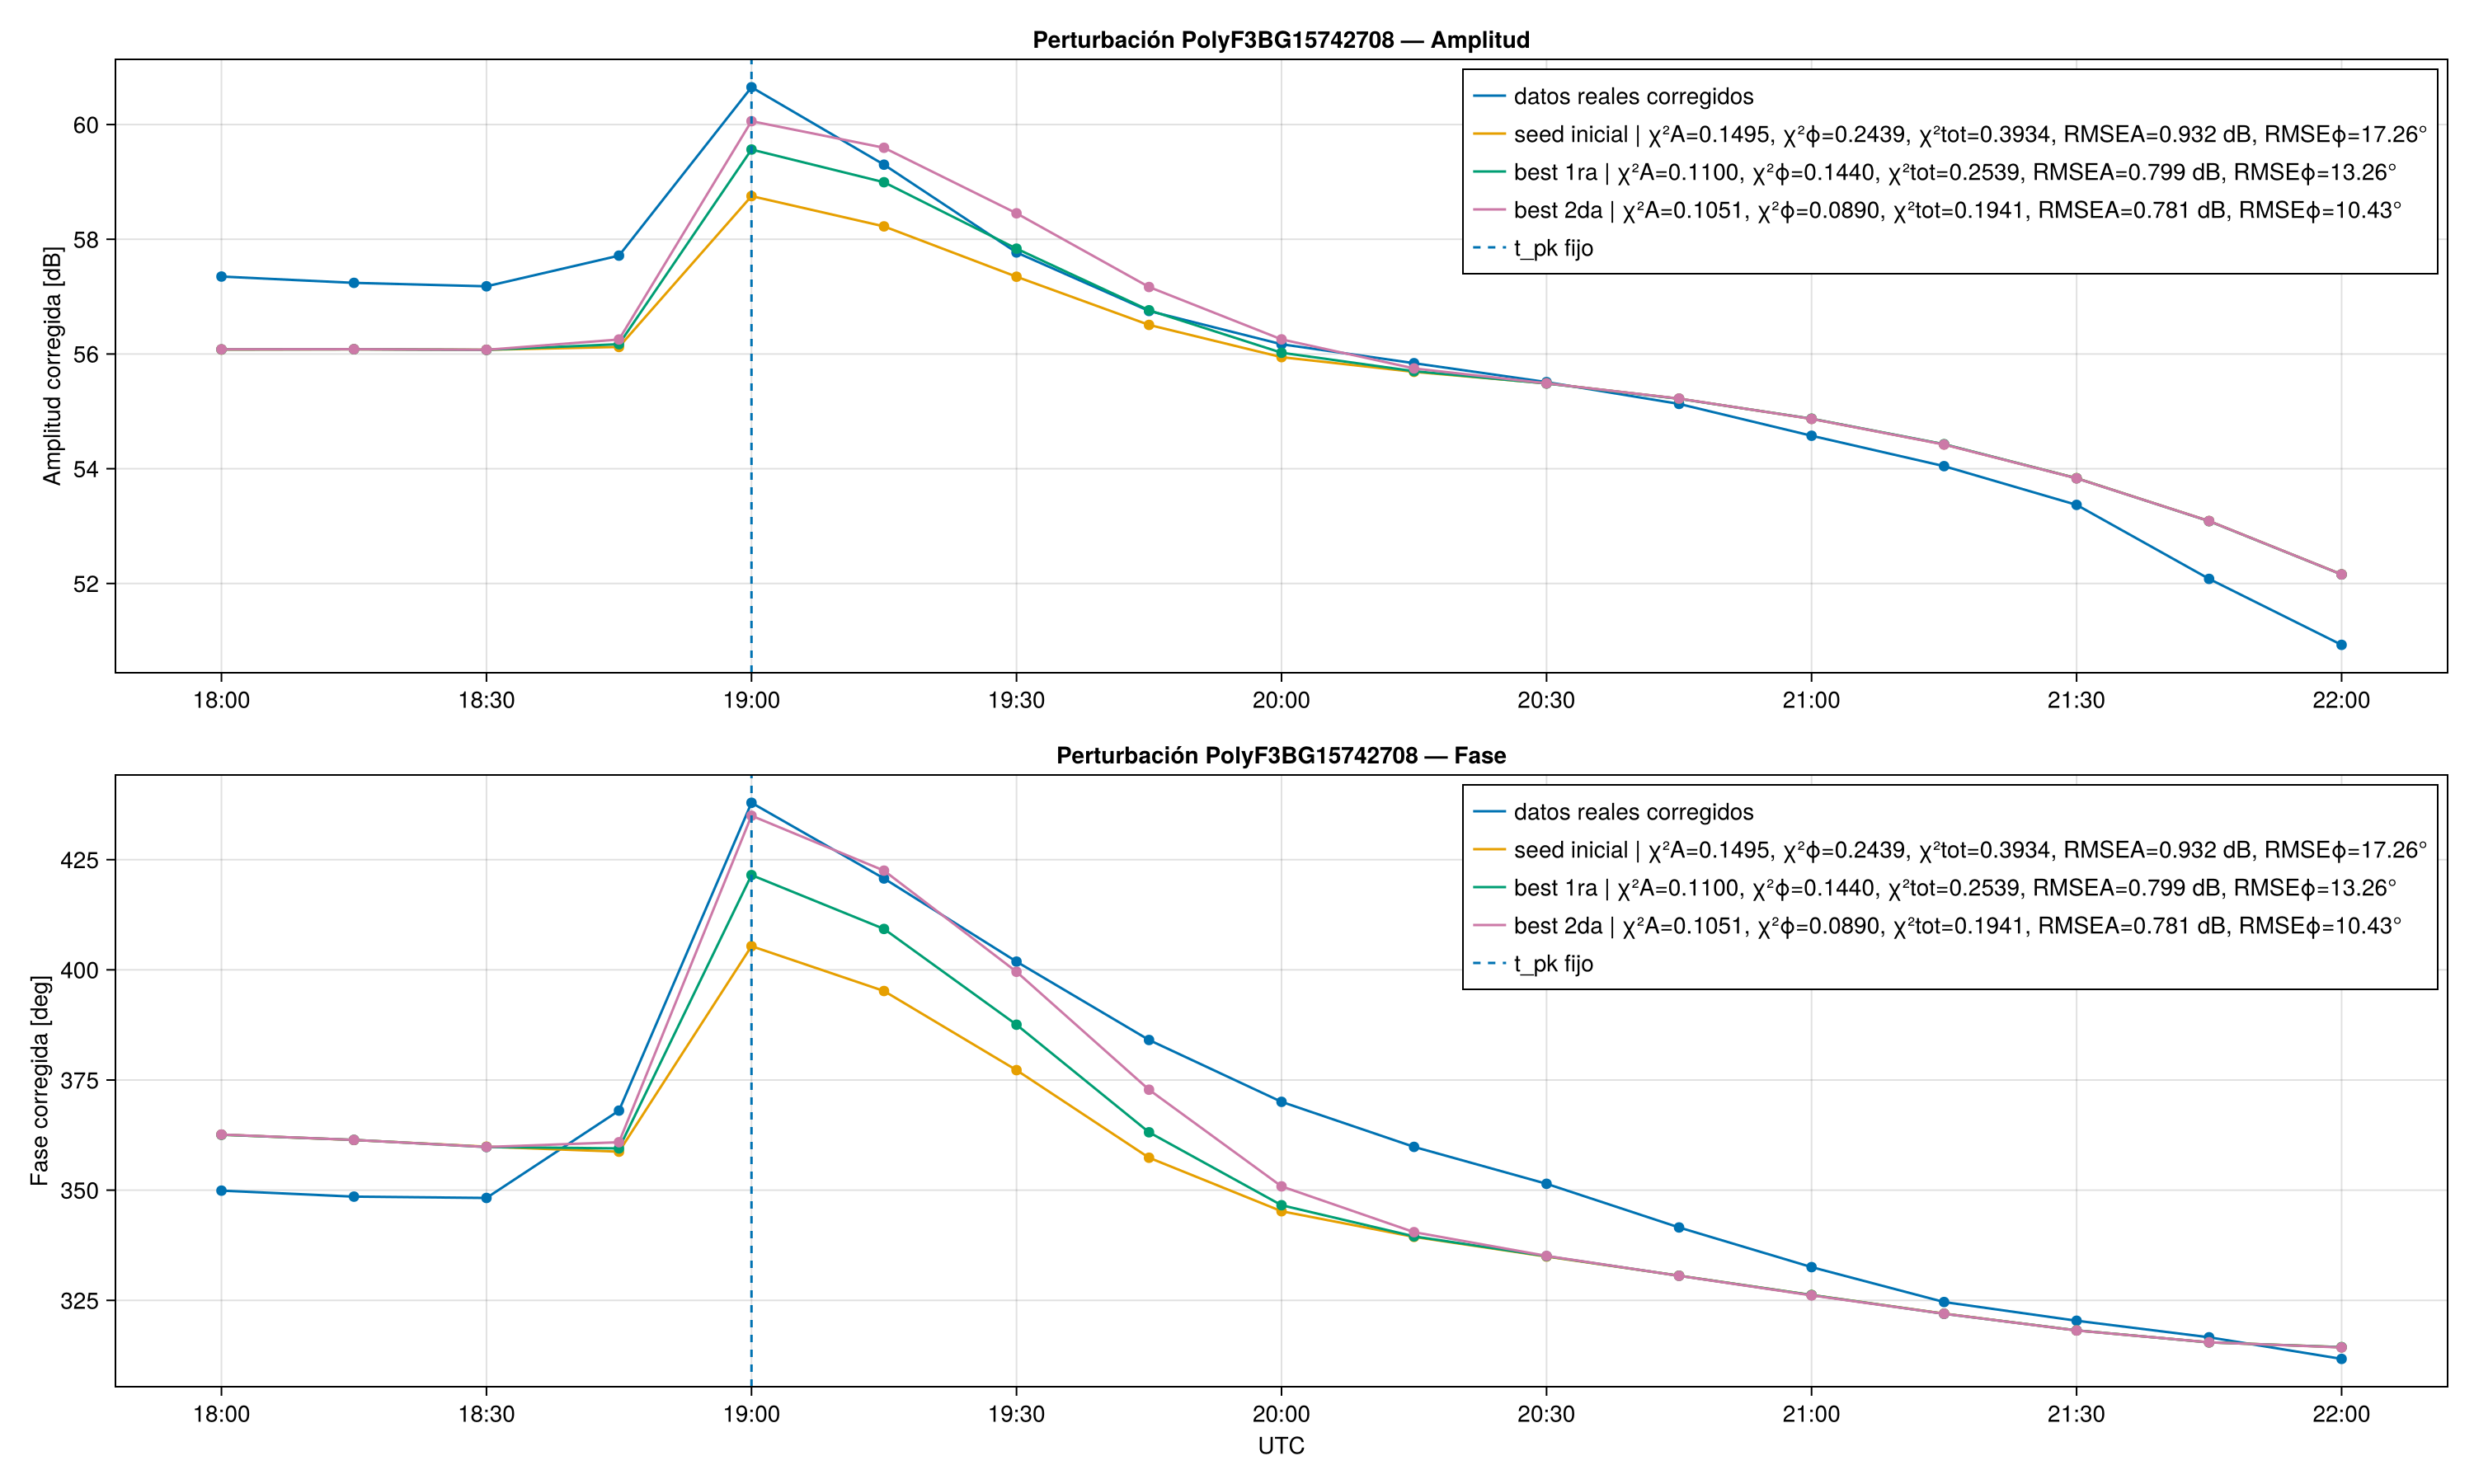

In [8]:

xt = collect(0:30:240)
xtlab = [Dates.format(dt[1] + Minute(Int(x)), "HH:MM") for x in xt]

fig_series = Figure(size = (1500, 900))

axA = Axis(
    fig_series[1, 1],
    title = "Perturbación PolyF3BG15742708 — Amplitud",
    ylabel = "Amplitud corregida [dB]",
    xticks = (xt, xtlab),
)

lines!(axA, t_min, A_target, label = "datos reales corregidos")
scatter!(axA, t_min, A_target)

lines!(axA, t_min, A_seed, label = metric_label("seed inicial", m_seed))
scatter!(axA, t_min, A_seed)

lines!(axA, t_min, A_best1, label = metric_label("best 1ra", m_best1))
scatter!(axA, t_min, A_best1)

lines!(axA, t_min, A_best2, label = metric_label("best 2da", m_best2))
scatter!(axA, t_min, A_best2)

axP = Axis(
    fig_series[2, 1],
    title = "Perturbación PolyF3BG15742708 — Fase",
    xlabel = "UTC",
    ylabel = "Fase corregida [deg]",
    xticks = (xt, xtlab),
)

lines!(axP, t_min, phi_target, label = "datos reales corregidos")
scatter!(axP, t_min, phi_target)

lines!(axP, t_min, phi_seed, label = metric_label("seed inicial", m_seed))
scatter!(axP, t_min, phi_seed)

lines!(axP, t_min, phi_best1, label = metric_label("best 1ra", m_best1))
scatter!(axP, t_min, phi_best1)

lines!(axP, t_min, phi_best2, label = metric_label("best 2da", m_best2))
scatter!(axP, t_min, phi_best2)

kpk = Int(read1(FIRST_H5, "fixed/t_pk_index"))
tpk_x = t_min[kpk]
vlines!(axA, [tpk_x], linestyle = :dash, label = "t_pk fijo")
vlines!(axP, [tpk_x], linestyle = :dash, label = "t_pk fijo")

axislegend(axA, position = :rt, framevisible = true)
axislegend(axP, position = :rt, framevisible = true)

fig_series



## 7. Residuales

Convención:

```text
residual = modelo - target
```


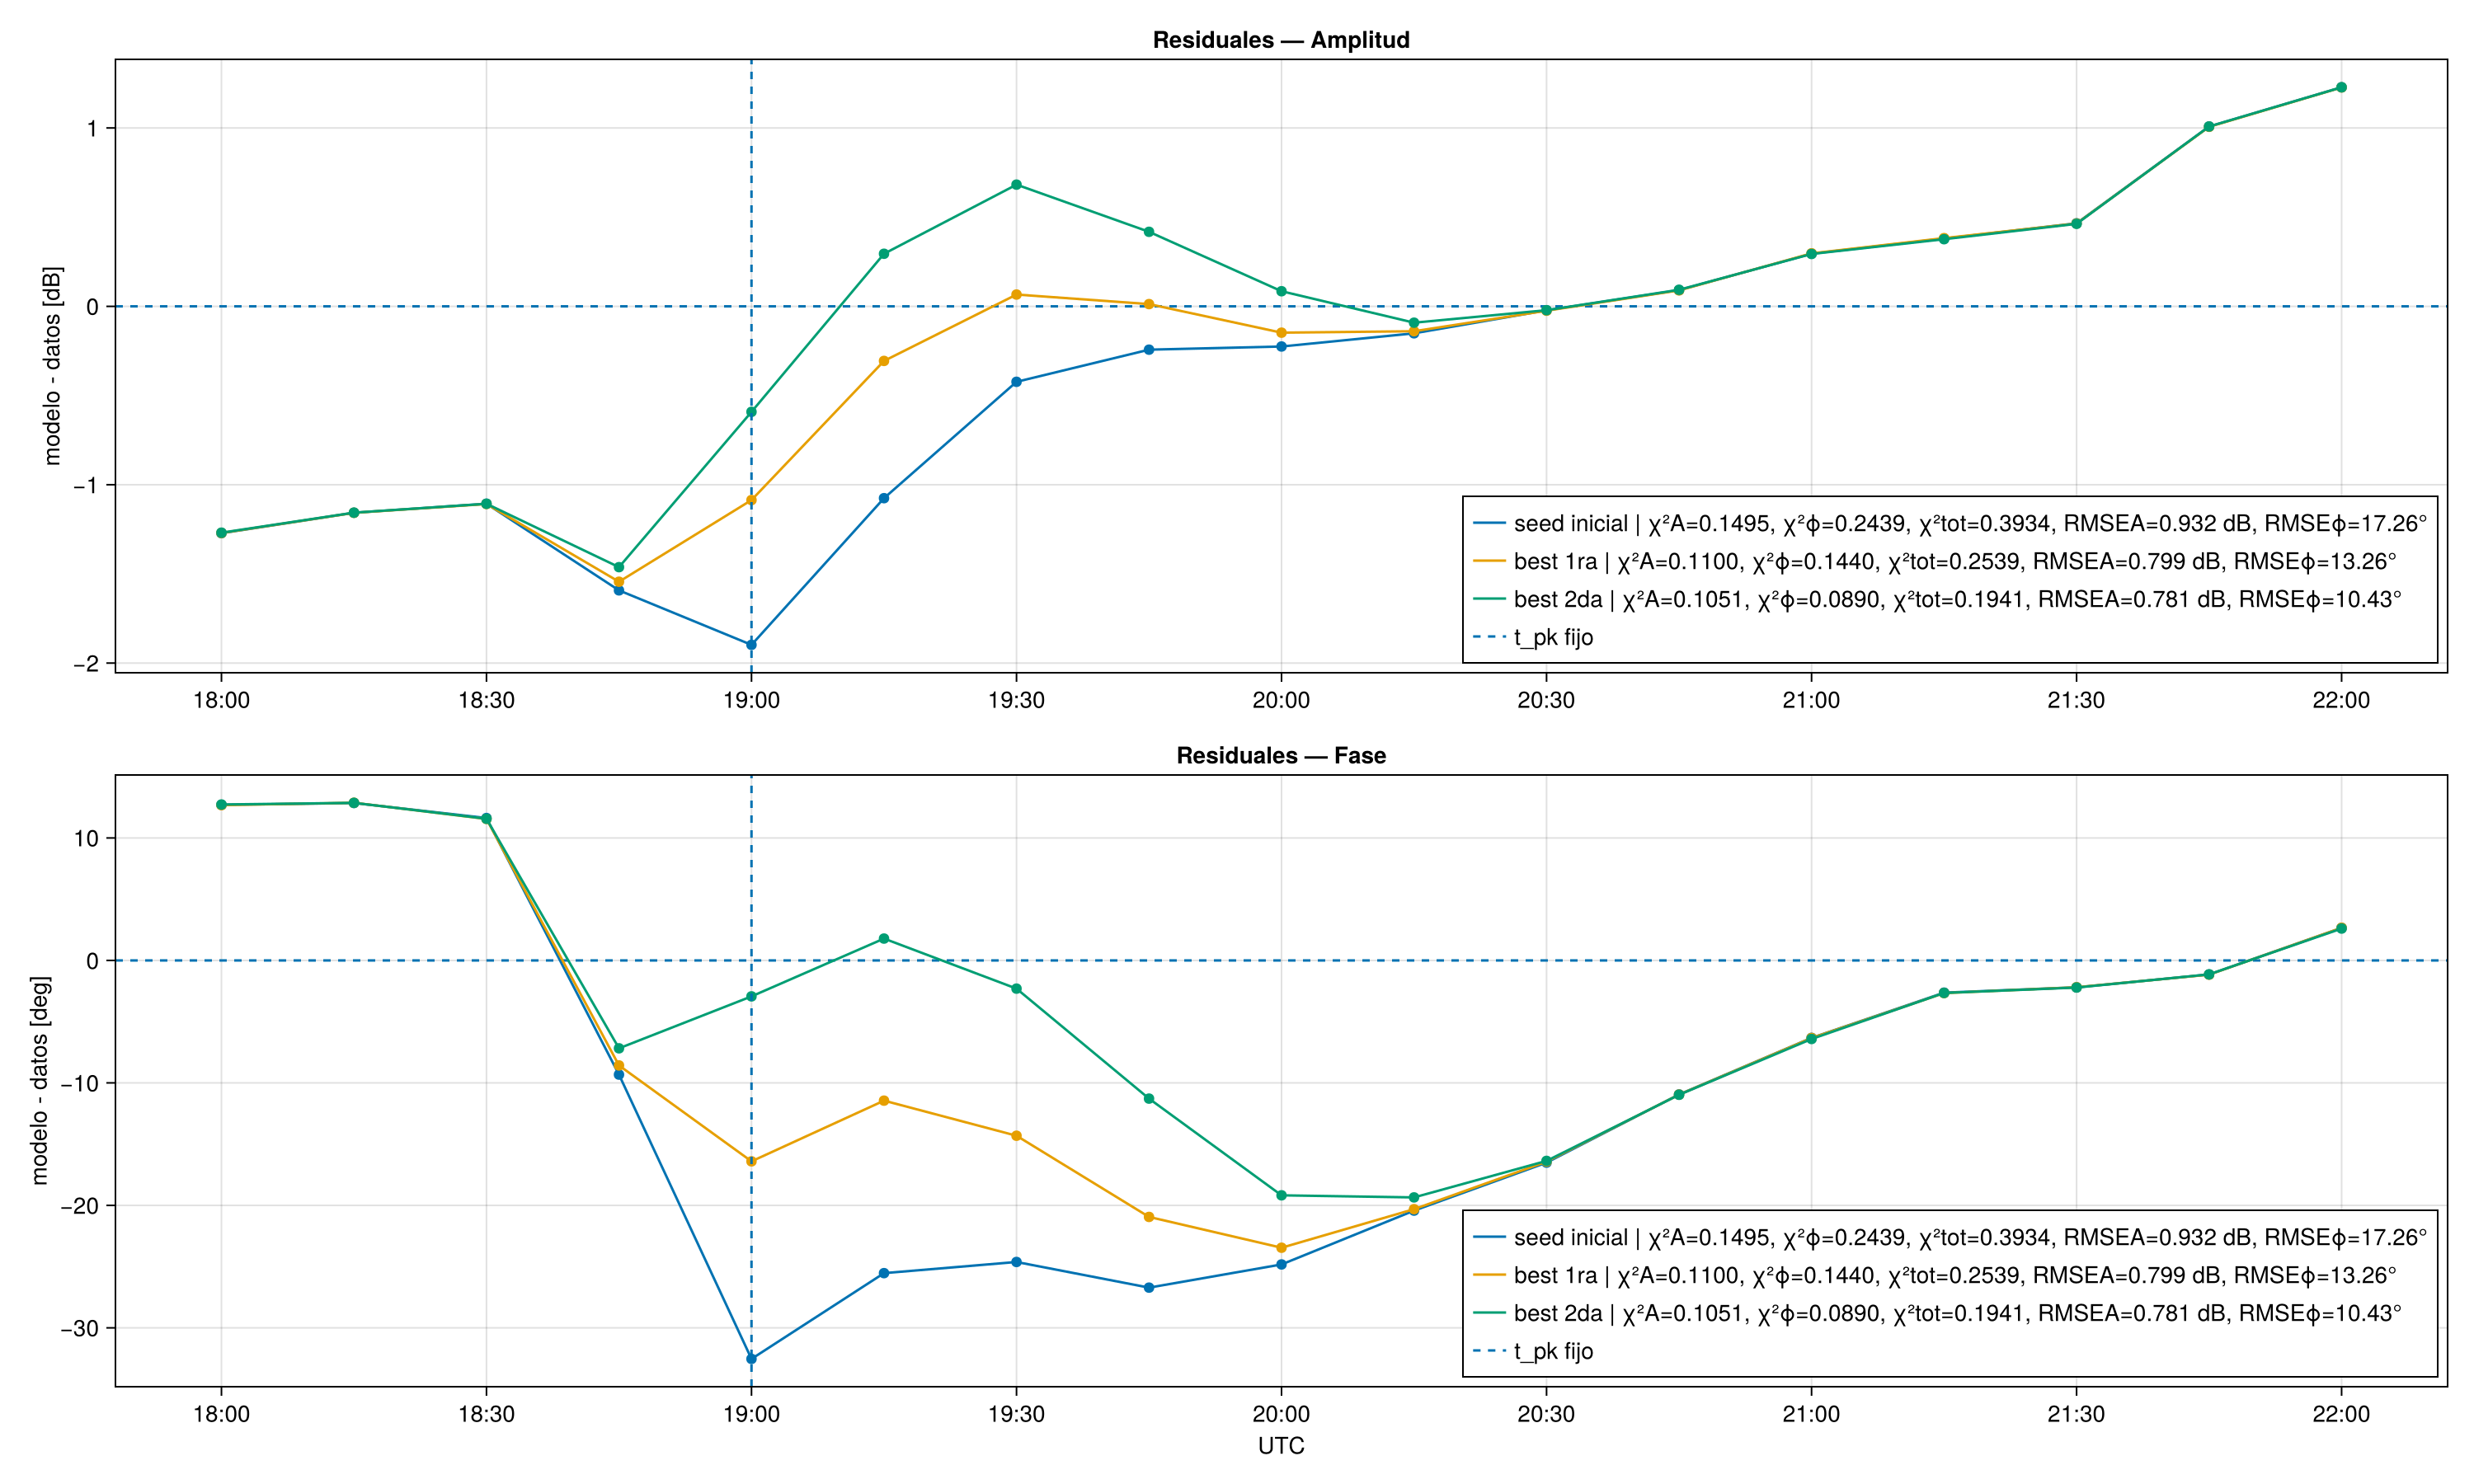

In [9]:

fig_res = Figure(size = (1500, 900))

axRA = Axis(
    fig_res[1, 1],
    title = "Residuales — Amplitud",
    ylabel = "modelo - datos [dB]",
    xticks = (xt, xtlab),
)
hlines!(axRA, [0.0], linestyle = :dash)

lines!(axRA, t_min, res_A_seed, label = metric_label("seed inicial", m_seed))
scatter!(axRA, t_min, res_A_seed)

lines!(axRA, t_min, res_A_best1, label = metric_label("best 1ra", m_best1))
scatter!(axRA, t_min, res_A_best1)

lines!(axRA, t_min, res_A_best2, label = metric_label("best 2da", m_best2))
scatter!(axRA, t_min, res_A_best2)

vlines!(axRA, [tpk_x], linestyle = :dash, label = "t_pk fijo")

axRP = Axis(
    fig_res[2, 1],
    title = "Residuales — Fase",
    xlabel = "UTC",
    ylabel = "modelo - datos [deg]",
    xticks = (xt, xtlab),
)
hlines!(axRP, [0.0], linestyle = :dash)

lines!(axRP, t_min, res_phi_seed, label = metric_label("seed inicial", m_seed))
scatter!(axRP, t_min, res_phi_seed)

lines!(axRP, t_min, res_phi_best1, label = metric_label("best 1ra", m_best1))
scatter!(axRP, t_min, res_phi_best1)

lines!(axRP, t_min, res_phi_best2, label = metric_label("best 2da", m_best2))
scatter!(axRP, t_min, res_phi_best2)

vlines!(axRP, [tpk_x], linestyle = :dash, label = "t_pk fijo")

axislegend(axRA, position = :rb, framevisible = true)
axislegend(axRP, position = :rb, framevisible = true)

fig_res



## 8. Tabla punto a punto de residuales


In [10]:

residuals_df = DataFrame(
    utc = Dates.format.(dt, "HH:MM"),
    t_min = t_min,
    res_A_seed = res_A_seed,
    res_A_best1 = res_A_best1,
    res_A_best2 = res_A_best2,
    res_phi_seed = res_phi_seed,
    res_phi_best1 = res_phi_best1,
    res_phi_best2 = res_phi_best2,
)

residuals_df


Row,utc,t_min,res_A_seed,res_A_best1,res_A_best2,res_phi_seed,res_phi_best1,res_phi_best2
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,18:00,0.0,-1.2718,-1.27064,-1.26886,12.7,12.6808,12.7302
2,18:15,15.0,-1.15729,-1.15745,-1.15651,12.8522,12.8713,12.8654
3,18:30,30.0,-1.10653,-1.10808,-1.1068,11.6264,11.5525,11.5647
4,18:45,45.0,-1.59233,-1.54385,-1.46218,-9.32364,-8.5753,-7.1764
5,19:00,60.0,-1.89782,-1.08604,-0.591527,-32.5362,-16.4053,-2.93531
6,19:15,75.0,-1.07546,-0.306005,0.294783,-25.533,-11.4487,1.78422
7,19:30,90.0,-0.423036,0.0661368,0.682381,-24.6224,-14.3145,-2.30304
8,19:45,105.0,-0.242888,0.0125919,0.417855,-26.7165,-20.9429,-11.2829
9,20:00,120.0,-0.225153,-0.14758,0.0847366,-24.8231,-23.459,-19.1796



## 9. Métricas por tramos temporales

Tramos usados:

- `18:00–19:15`: inicio y pico;
- `19:30–20:30`: recuperación temprana;
- `20:45–22:00`: cola final.


In [11]:

segments = [
    ("18:00–19:15", t_min .<= 75),
    ("19:30–20:30", (t_min .>= 90) .& (t_min .<= 150)),
    ("20:45–22:00", t_min .>= 165),
]

seg_rows = NamedTuple[]
for (name, mask) in segments
    push!(seg_rows, (
        tramo = name,
        RMSE_A_seed = rmse(res_A_seed[mask]),
        RMSE_A_best1 = rmse(res_A_best1[mask]),
        RMSE_A_best2 = rmse(res_A_best2[mask]),
        RMSE_phi_seed = rmse(res_phi_seed[mask]),
        RMSE_phi_best1 = rmse(res_phi_best1[mask]),
        RMSE_phi_best2 = rmse(res_phi_best2[mask]),
    ))
end

segment_df = DataFrame(seg_rows)
segment_df


Row,tramo,RMSE_A_seed,RMSE_A_best1,RMSE_A_best2,RMSE_phi_seed,RMSE_phi_best1,RMSE_phi_best2
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,18:00–19:15,1.38294,1.143,1.06045,19.4041,12.4745,9.35073
2,19:30–20:30,0.249798,0.0963025,0.362296,22.9176,19.3709,15.1178
3,20:45–22:00,0.704959,0.704461,0.704148,5.47521,5.48532,5.50074



## 10. Score usado para fijar `t_pk`

El pico fijo se obtuvo desde las perturbaciones crudas PolyF3 mediante:

```text
score = sqrt((ΔA / σA)^2 + (Δϕ / σϕ)^2)
```


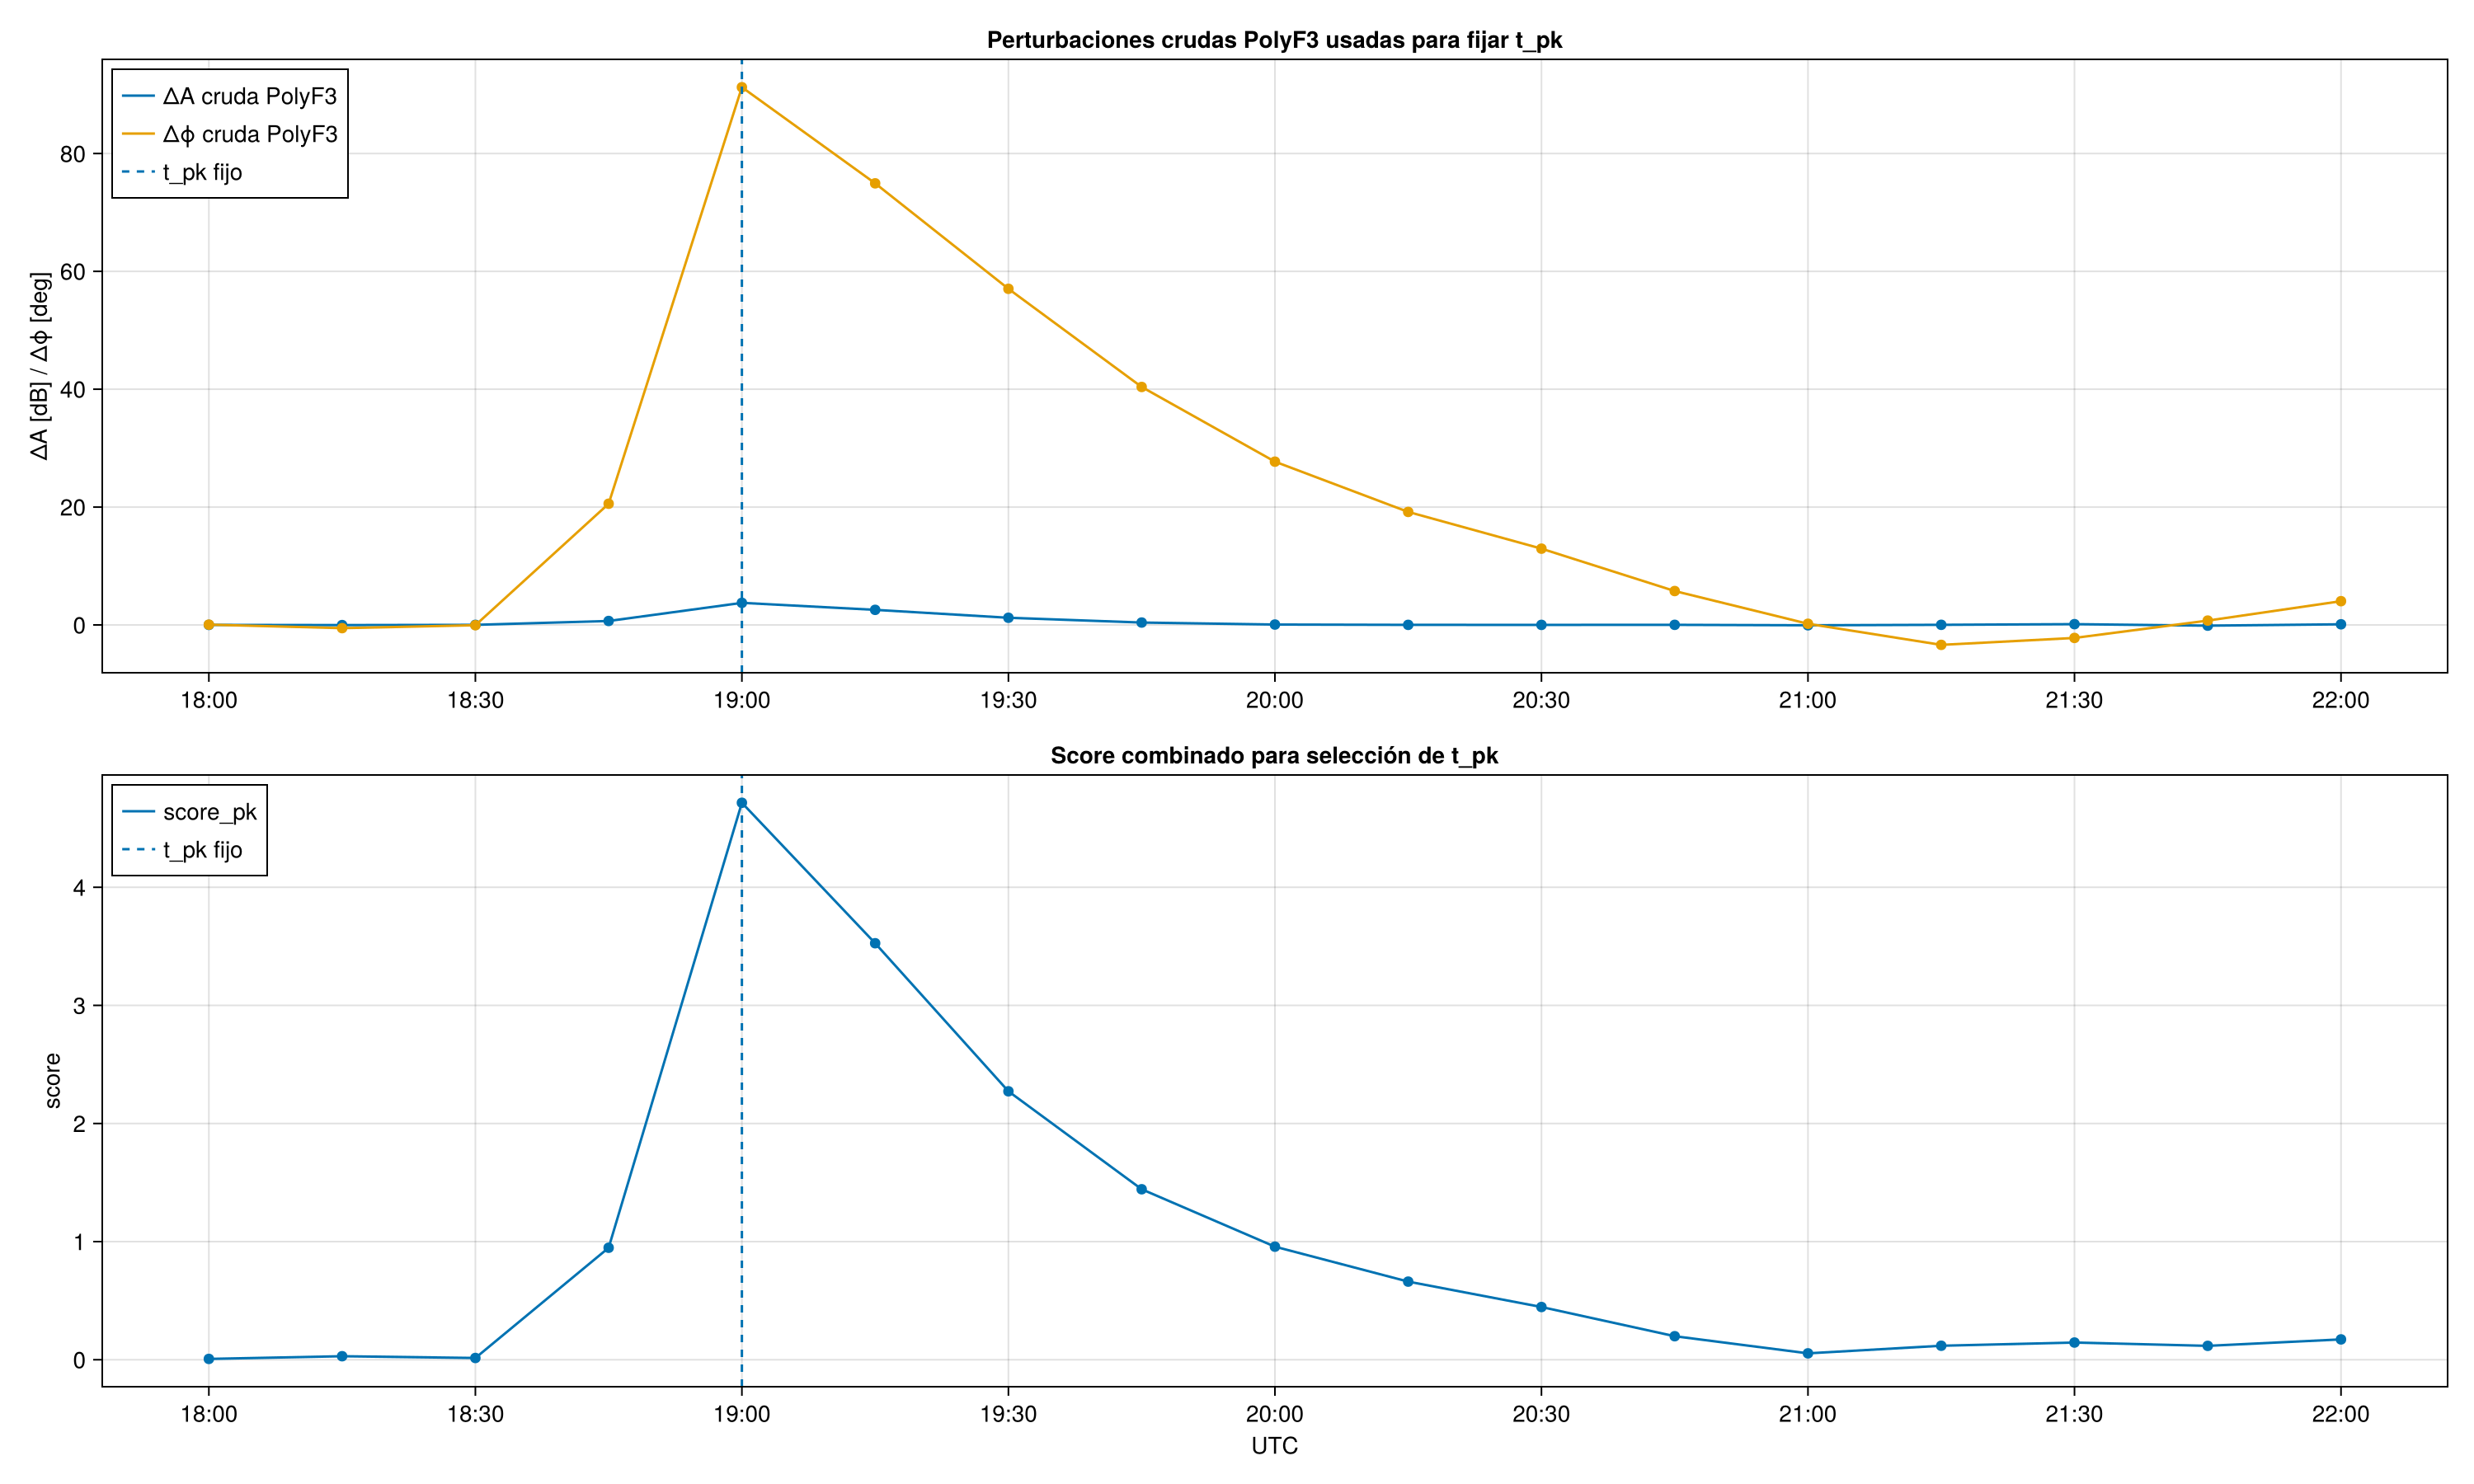

In [12]:

ΔA_pk = h5read(FIRST_H5, "fixed/delta_A_for_peak")
Δϕ_pk = h5read(FIRST_H5, "fixed/delta_phi_for_peak")
score_pk = h5read(FIRST_H5, "fixed/score_pk")

fig_pk = Figure(size = (1500, 900))

ax1 = Axis(
    fig_pk[1, 1],
    title = "Perturbaciones crudas PolyF3 usadas para fijar t_pk",
    ylabel = "ΔA [dB] / Δϕ [deg]",
    xticks = (xt, xtlab),
)
lines!(ax1, t_min, ΔA_pk, label = "ΔA cruda PolyF3")
scatter!(ax1, t_min, ΔA_pk)
lines!(ax1, t_min, Δϕ_pk, label = "Δϕ cruda PolyF3")
scatter!(ax1, t_min, Δϕ_pk)
vlines!(ax1, [tpk_x], linestyle = :dash, label = "t_pk fijo")
axislegend(ax1, position = :lt, framevisible = true)

ax2 = Axis(
    fig_pk[2, 1],
    title = "Score combinado para selección de t_pk",
    xlabel = "UTC",
    ylabel = "score",
    xticks = (xt, xtlab),
)
lines!(ax2, t_min, score_pk, label = "score_pk")
scatter!(ax2, t_min, score_pk)
vlines!(ax2, [tpk_x], linestyle = :dash, label = "t_pk fijo")
axislegend(ax2, position = :lt, framevisible = true)

fig_pk



## 11. Guardar figuras principales

Esta celda es opcional. Guarda las figuras en PNG dentro del directorio `figuras_analisis_polyF3BG15742708_perturbacion`.


In [13]:

outdir = "figuras_analisis_polyF3BG15742708_perturbacion"
mkpath(outdir)

save(joinpath(outdir, "series_seed_best1_best2_polyF3BG15742708.png"), fig_series)
save(joinpath(outdir, "residuales_seed_best1_best2_polyF3BG15742708.png"), fig_res)
save(joinpath(outdir, "score_tpk_polyF3BG15742708.png"), fig_pk)

println("Figuras guardadas en: ", abspath(outdir))


Figuras guardadas en: /home/jp/basefolder_JP/figuras_analisis_polyF3BG15742708_perturbacion



## 12. Conclusión automática mínima

La celda siguiente imprime una lectura compacta basada únicamente en las métricas cargadas desde los HDF5.


In [14]:

println("Resumen cuantitativo")
println("====================")
@printf("χ²_total seed        = %.6f\n", m_seed.chi2_total)
@printf("χ²_total best 1ra    = %.6f\n", m_best1.chi2_total)
@printf("χ²_total best 2da    = %.6f\n", m_best2.chi2_total)
println()
@printf("Mejora best 1ra vs seed     = %.2f %%\n", pct_improvement(m_seed.chi2_total, m_best1.chi2_total))
@printf("Mejora best 2da vs best 1ra = %.2f %%\n", pct_improvement(m_best1.chi2_total, m_best2.chi2_total))
@printf("Mejora best 2da vs seed     = %.2f %%\n", pct_improvement(m_seed.chi2_total, m_best2.chi2_total))
println()
@printf("RMSE_A:   seed %.4f dB  → best 1ra %.4f dB → best 2da %.4f dB\n", m_seed.rmse_A, m_best1.rmse_A, m_best2.rmse_A)
@printf("RMSE_phi: seed %.4f°    → best 1ra %.4f°   → best 2da %.4f°\n", m_seed.rmse_phi, m_best1.rmse_phi, m_best2.rmse_phi)
println()
println("Best actual recomendado para la cadena PolyF3BG15742708: job 15868514.")


Resumen cuantitativo
χ²_total seed        = 0.393377
χ²_total best 1ra    = 0.253942
χ²_total best 2da    = 0.194083

Mejora best 1ra vs seed     = 35.45 %
Mejora best 2da vs best 1ra = 23.57 %
Mejora best 2da vs seed     = 50.66 %

RMSE_A:   seed 0.9321 dB  → best 1ra 0.7994 dB → best 2da 0.7813 dB
RMSE_phi: seed 17.2611°    → best 1ra 13.2629°   → best 2da 10.4288°

Best actual recomendado para la cadena PolyF3BG15742708: job 15868514.


In [15]:
####################################################################################################
# Evaluación forward 5 min — seed inicial, best 1ra corrida y best 2da corrida
#
# Correcciones:
#   - NO asume rutas absolutas del servidor MIT.
#   - Si separation_source_h5 viene como /orcd/.../archivo.h5, usa basename(...) y busca localmente.
#   - No intenta remover el proceso principal 1.
#   - 3 workers, 1 thread por worker.
#   - Una evaluación por worker.
####################################################################################################

using Distributed
using HDF5
using Dates
using TimeZones
using DataFrames
using Statistics
using LinearAlgebra

# --------------------------------------------------------------------------------------------------
# 1. Crear exactamente 3 workers reales de 1 thread
# --------------------------------------------------------------------------------------------------

ENV["OPENBLAS_NUM_THREADS"] = "1"
ENV["MKL_NUM_THREADS"] = "1"
ENV["BLIS_NUM_THREADS"] = "1"
ENV["OMP_NUM_THREADS"] = "1"
ENV["OPENBLAS_MAIN_FREE"] = "1"
ENV["JULIA_HDF5_USE_SYSTEM_LIBHDF5"] = "0"

old_workers = setdiff(workers(), [1])

if !isempty(old_workers)
    println("Removiendo workers existentes: ", old_workers)
    rmprocs(old_workers)
end

println("Agregando 3 workers con -t 1 ...")

addprocs(
    3;
    exeflags = `--project=. -t 1`,
    env = [
        "JULIA_NUM_THREADS" => "1",
        "OPENBLAS_NUM_THREADS" => "1",
        "MKL_NUM_THREADS" => "1",
        "BLIS_NUM_THREADS" => "1",
        "OMP_NUM_THREADS" => "1",
        "OPENBLAS_MAIN_FREE" => "1",
        "JULIA_HDF5_USE_SYSTEM_LIBHDF5" => "0",
    ],
)

eval_workers_5min = workers()[1:3]

@everywhere eval_workers_5min begin
    ENV["OPENBLAS_NUM_THREADS"] = "1"
    ENV["MKL_NUM_THREADS"] = "1"
    ENV["BLIS_NUM_THREADS"] = "1"
    ENV["OMP_NUM_THREADS"] = "1"
    ENV["OPENBLAS_MAIN_FREE"] = "1"
    ENV["JULIA_HDF5_USE_SYSTEM_LIBHDF5"] = "0"

    using Dates
    using TimeZones
    using JLD2
    using Polynomials
    using AstroLib
    using DSP
    using LinearAlgebra
    using Interpolations

    BLAS.set_num_threads(1)

    include("./mytools/preamble.jl")
    include("./mytools/scenario.jl")
end

println("Workers usados:")
for (lab, w) in zip(["seed inicial", "best 1ra", "best 2da"], eval_workers_5min)
    info = remotecall_fetch(
        () -> (
            id = myid(),
            threads = Threads.nthreads(),
            blas = LinearAlgebra.BLAS.get_num_threads(),
        ),
        w,
    )

    println("  $(lab) → worker $(w), Threads=$(info.threads), BLAS=$(info.blas)")
end

# --------------------------------------------------------------------------------------------------
# 2. Función remota única de evaluación forward
# --------------------------------------------------------------------------------------------------

@everywhere eval_workers_5min function eval_perturbation_5min(
    label::String,
    p_full::Vector{Float64},
    h_coeffs::Vector{Float64},
    beta_coeffs::Vector{Float64},
    timestamps_5min::Vector{Float64},
)
    UTC = TimeZone("UTC")

    function chi_signed(lat_deg, lon_deg, zdt::ZonedDateTime)
        zdt_utc = astimezone(zdt, UTC)
        jd = AstroLib.jdcnv(DateTime(zdt_utc))
        ra, dec = AstroLib.sunpos(jd)

        alt_deg, az_deg, _ = AstroLib.eq2hor(
            ra,
            dec,
            jd,
            lat_deg,
            lon_deg,
            0.0,
        )

        sza = 90.0 - alt_deg
        return (0.0 <= az_deg < 180.0) ? -sza : +sza
    end

    function unwrap_against_firi(t_ref, phi_wr_ref, t_new, phi_wr_new)
        phi_ref_unw = DSP.unwrap(
            collect(float.(phi_wr_ref));
            dims = 1,
            discont = 0.9π,
            period = 2π,
        )

        to_ms(zdt_vec) = Float64.(
            Dates.value.(DateTime.(astimezone.(zdt_vec, Ref(UTC))))
        )

        x_ref = to_ms(t_ref)
        x_new = to_ms(t_new)

        itp = Interpolations.LinearInterpolation(
            x_ref,
            phi_ref_unw;
            extrapolation_bc = Interpolations.Linear(),
        )

        phi_ref_at_new = itp.(x_new)

        phi_wr_new = collect(float.(phi_wr_new))
        phi_unw_new = similar(phi_wr_new)

        @inbounds for k in eachindex(phi_wr_new)
            m = round((phi_ref_at_new[k] - phi_wr_new[k]) / (2π))
            phi_unw_new[k] = phi_wr_new[k] + m * 2π
        end

        return phi_unw_new
    end

    @inline nexp(z_km, z0, hz) = exp(clamp((z_km - z0) / hz, -50.0, 50.0))

    @inline function gauss_asym(Δt, amp, t_pk, tau_u, tau_d, eps_t)
        w = tau_u + 0.5 * (tau_d - tau_u) * (1.0 + tanh((Δt - t_pk) / eps_t))
        return amp * exp(-0.5 * ((Δt - t_pk) / w)^2)
    end

    @inline function ne_perturb(z, h_i, beta_i, Δt, amp, t_pk, tau_u, tau_d, eps_t, z0, hz)
        ne_bg = waitprofile(z, h_i, beta_i)

        return ne_bg * (
            1.0 +
            nexp(z / 1e3, z0, hz) *
            gauss_asym(Δt, amp, t_pk, tau_u, tau_d, eps_t)
        )
    end

    amp, t_pk, tau_u, tau_d, eps_t, z0, hz = p_full

    p_h = Polynomial(h_coeffs)
    p_beta = Polynomial(beta_coeffs)

    phi_firi_wrapped_ref = nothing
    zdt_ref = nothing

    jldopen("./reference-efield-firi.jld2", "r") do jf
        phi_firi_wrapped_ref = jf["phi"]
        zdt_ref = jf["zdt"]
    end

    npoints = 19
    lats, lons, dists = geolinspace("NAA", "PLO", npoints, false)

    lon_rx = rx_params["Longitude"]
    lat_rx = rx_params["Latitude"]
    rx_rec = Receiver("PLO", lat_rx, lon_rx, 0.0, VerticalDipole())

    d12 = Float64.(dists[1:2:end])
    d22 = Float64.(dists[2:2:end])

    zdt_5min = ZonedDateTime.(unix2datetime.(timestamps_5min), UTC)
    nt = length(zdt_5min)

    A_model = Vector{Float64}(undef, nt)
    phi_wrapped = Vector{Float64}(undef, nt)

    t0 = ZonedDateTime(2008, 3, 25, 18, 30, 0, UTC)

    for k in eachindex(zdt_5min)
        tt = zdt_5min[k]
        Δt = Dates.value(DateTime(tt) - DateTime(t0)) / 1000.0

        sza = chi_signed.(lats, lons, Ref(tt))
        rad_sza_mid = (π / 180.0) .* sza[2:2:end]

        hs = p_h.(rad_sza_mid)
        betas = p_beta.(rad_sza_mid)

        bf = igrf(tx2, rx_rec, year(tt), d22; alt = 60e3)

        species = Vector{Any}(undef, length(d22))

        for j in eachindex(d22)
            h_j = hs[j]
            beta_j = betas[j]

            species[j] = Species(
                QE,
                ME,
                z -> ne_perturb(
                    z,
                    h_j,
                    beta_j,
                    Δt,
                    amp,
                    t_pk,
                    tau_u,
                    tau_d,
                    eps_t,
                    z0,
                    hz,
                ),
                electroncollisionfrequency,
            )
        end

        wg = SegmentedWaveguide([
            HomogeneousWaveguide(
                bf[j],
                species[j],
                ground,
                d12[j],
            )
            for j in eachindex(d22)
        ])

        _, A_k, phi_k = propagate(wg, tx2, rx)

        A_model[k] = Float64(A_k)
        phi_wrapped[k] = Float64(phi_k)
    end

    phi_model = rad2deg.(unwrap_against_firi(zdt_ref, phi_firi_wrapped_ref, zdt_5min, phi_wrapped))

    return (
        label = label,
        worker = myid(),
        A = A_model,
        phi = phi_model,
    )
end

# --------------------------------------------------------------------------------------------------
# 3. Resolver archivo local de separación PolyF3
# --------------------------------------------------------------------------------------------------

@assert @isdefined(FIRST_H5) "Falta FIRST_H5 en el notebook."
@assert @isdefined(SECOND_H5) "Falta SECOND_H5 en el notebook."

function attr_as_string(v)
    if v isa AbstractString
        return String(v)
    elseif v isa AbstractVector{UInt8}
        return String(v)
    elseif v isa AbstractArray && length(v) == 1
        return string(v[1])
    else
        return string(v)
    end
end

function local_h5_from_any_path(path_from_attr::AbstractString)
    fname = basename(path_from_attr)

    candidates = String[
        path_from_attr,
        fname,
        joinpath(pwd(), fname),
        joinpath(dirname(abspath(FIRST_H5)), fname),
        joinpath(dirname(abspath(SECOND_H5)), fname),
        joinpath("/mnt/data", fname),
    ]

    for c in candidates
        if isfile(c)
            return abspath(c)
        end
    end

    # Último intento: buscar por nombre en el directorio actual y en /mnt/data.
    for root0 in unique([pwd(), "/mnt/data"])
        isdir(root0) || continue

        for (root, _dirs, files) in walkdir(root0)
            if fname in files
                return abspath(joinpath(root, fname))
            end
        end
    end

    error(
        "No encuentro localmente el HDF5 de separación PolyF3.\n" *
        "Ruta guardada en el HDF5: $(path_from_attr)\n" *
        "Nombre buscado localmente: $(fname)\n" *
        "Solución: coloca $(fname) en el mismo directorio del notebook o define manualmente:\n" *
        "    separation_h5 = \"/ruta/local/$(fname)\""
    )
end

separation_h5_attr = HDF5.h5open(FIRST_H5, "r") do f
    attrs = HDF5.attributes(f)

    if haskey(attrs, "separation_source_h5")
        attr_as_string(read(attrs["separation_source_h5"]))
    else
        "simultaneous_polyF3_NAA_V_20080325_window16_22_degA7_degPhi4.h5"
    end
end

separation_h5 = local_h5_from_any_path(separation_h5_attr)

println("Separación PolyF3 usada:")
println("  atributo original = ", separation_h5_attr)
println("  archivo local     = ", separation_h5)

# --------------------------------------------------------------------------------------------------
# 4. Construir target real de 5 min desde separación PolyF3
# --------------------------------------------------------------------------------------------------

t_sep_raw = HDF5.h5read(separation_h5, "time_unix")
t_sep = Float64.(vec(t_sep_raw))
t_sep = median(abs.(t_sep)) > 1e11 ? t_sep ./ 1000.0 : t_sep

A_real_sep = HDF5.h5open(separation_h5, "r") do f
    if haskey(f, "A_real")
        Float64.(vec(read(f["A_real"])))
    else
        Float64.(vec(read(f["A_background"]))) .+ Float64.(vec(read(f["A_perturbation_raw"])))
    end
end

phi_real_sep = HDF5.h5open(separation_h5, "r") do f
    if haskey(f, "phi_real")
        Float64.(vec(read(f["phi_real"])))
    else
        Float64.(vec(read(f["phi_background"]))) .+ Float64.(vec(read(f["phi_perturbation_raw"])))
    end
end

dt_sep = DateTime(1970, 1, 1) .+ Second.(round.(Int, t_sep))

dt_5min = collect(DateTime(2008, 3, 25, 18, 0, 0):Minute(5):DateTime(2008, 3, 25, 22, 0, 0))
timestamps_5min = Float64.(datetime2unix.(dt_5min))
t_min_5min = Float64.(Dates.value.(dt_5min .- dt_5min[1])) ./ 60000.0

index_map = Dict(dt => i for (i, dt) in enumerate(dt_sep))
idx_5min = Vector{Int}(undef, length(dt_5min))

for (k, dt) in enumerate(dt_5min)
    if haskey(index_map, dt)
        idx_5min[k] = index_map[dt]
    else
        diffs = abs.(Dates.value.(dt_sep .- dt))
        idx_5min[k] = argmin(diffs)
        println("Sin match exacto para $(dt); usando $(dt_sep[idx_5min[k]])")
    end
end

amp_offset_5min = HDF5.h5open(FIRST_H5, "r") do f
    attrs = HDF5.attributes(f)

    if haskey(attrs, "amp_offset_db_used")
        v = read(attrs["amp_offset_db_used"])
        v isa AbstractArray ? Float64(v[1]) : Float64(v)
    else
        19.0
    end
end

phi_offset_5min = HDF5.h5open(FIRST_H5, "r") do f
    attrs = HDF5.attributes(f)

    if haskey(attrs, "phi_offset_deg_used")
        v = read(attrs["phi_offset_deg_used"])
        v isa AbstractArray ? Float64(v[1]) : Float64(v)
    else
        -210.0
    end
end

A_target_5min = A_real_sep[idx_5min] .+ amp_offset_5min
phi_target_5min = phi_real_sep[idx_5min] .+ phi_offset_5min

println("Grilla 5 min:")
println("  N = ", length(dt_5min))
println("  rango = ", first(dt_5min), " → ", last(dt_5min))
println("  offsets: A += ", amp_offset_5min, " dB, phi += ", phi_offset_5min, " deg")

# --------------------------------------------------------------------------------------------------
# 5. Parámetros seed / best1 / best2 y background físico
# --------------------------------------------------------------------------------------------------

p_seed_full_5min = Float64.(vec(HDF5.h5read(FIRST_H5, "initial/full_params")))
p_best1_full_5min = Float64.(vec(HDF5.h5read(FIRST_H5, "reconstruction/full_params")))
p_best2_full_5min = Float64.(vec(HDF5.h5read(SECOND_H5, "reconstruction/full_params")))

h_coeffs_5min = Float64.(vec(HDF5.h5read(FIRST_H5, "background/h_coeffs")))
beta_coeffs_5min = Float64.(vec(HDF5.h5read(FIRST_H5, "background/beta_coeffs")))

println("Parámetros completos:")
println("  seed inicial = ", p_seed_full_5min)
println("  best 1ra     = ", p_best1_full_5min)
println("  best 2da     = ", p_best2_full_5min)

# --------------------------------------------------------------------------------------------------
# 6. Evaluar los tres casos en paralelo
# --------------------------------------------------------------------------------------------------
# --------------------------------------------------------------------------------------------------
# 6. Evaluar los tres casos en paralelo
#
# Importante:
# eval_perturbation_5min está definido en los workers, no necesariamente en Main local.
# Por eso se llama como Main.eval_perturbation_5min dentro de una closure ejecutada remotamente.
# --------------------------------------------------------------------------------------------------

println("\nLanzando evaluaciones forward 5 min...")

task_seed = @async remotecall_fetch(
    (label, p, h, β, ts) -> Main.eval_perturbation_5min(label, p, h, β, ts),
    eval_workers_5min[1],
    "seed inicial",
    p_seed_full_5min,
    h_coeffs_5min,
    beta_coeffs_5min,
    timestamps_5min,
)

task_best1 = @async remotecall_fetch(
    (label, p, h, β, ts) -> Main.eval_perturbation_5min(label, p, h, β, ts),
    eval_workers_5min[2],
    "best 1ra",
    p_best1_full_5min,
    h_coeffs_5min,
    beta_coeffs_5min,
    timestamps_5min,
)

task_best2 = @async remotecall_fetch(
    (label, p, h, β, ts) -> Main.eval_perturbation_5min(label, p, h, β, ts),
    eval_workers_5min[3],
    "best 2da",
    p_best2_full_5min,
    h_coeffs_5min,
    beta_coeffs_5min,
    timestamps_5min,
)

results_5min = fetch.([task_seed, task_best1, task_best2])

println("Evaluaciones terminadas:")
for r in results_5min
    println("  ", r.label, " → worker ", r.worker)
end

by_label = Dict(r.label => r for r in results_5min)

A_seed_5min = by_label["seed inicial"].A
phi_seed_5min = by_label["seed inicial"].phi

A_best1_5min = by_label["best 1ra"].A
phi_best1_5min = by_label["best 1ra"].phi

A_best2_5min = by_label["best 2da"].A
phi_best2_5min = by_label["best 2da"].phi

# --------------------------------------------------------------------------------------------------
# 7. Métricas y residuales 5 min
# --------------------------------------------------------------------------------------------------

res_A_seed_5min = A_seed_5min .- A_target_5min
res_phi_seed_5min = phi_seed_5min .- phi_target_5min

res_A_best1_5min = A_best1_5min .- A_target_5min
res_phi_best1_5min = phi_best1_5min .- phi_target_5min

res_A_best2_5min = A_best2_5min .- A_target_5min
res_phi_best2_5min = phi_best2_5min .- phi_target_5min

chi2norm(model, target) = sum((model .- target).^2) / (sum((target .- mean(target)).^2) + 1e-12)
rmse5(model, target) = sqrt(mean((model .- target).^2))

metrics_5min_df = DataFrame(
    caso = ["seed inicial", "best 1ra", "best 2da"],
    worker = [
        by_label["seed inicial"].worker,
        by_label["best 1ra"].worker,
        by_label["best 2da"].worker,
    ],
    chi2_A = [
        chi2norm(A_seed_5min, A_target_5min),
        chi2norm(A_best1_5min, A_target_5min),
        chi2norm(A_best2_5min, A_target_5min),
    ],
    chi2_phi = [
        chi2norm(phi_seed_5min, phi_target_5min),
        chi2norm(phi_best1_5min, phi_target_5min),
        chi2norm(phi_best2_5min, phi_target_5min),
    ],
    RMSE_A_dB = [
        rmse5(A_seed_5min, A_target_5min),
        rmse5(A_best1_5min, A_target_5min),
        rmse5(A_best2_5min, A_target_5min),
    ],
    RMSE_phi_deg = [
        rmse5(phi_seed_5min, phi_target_5min),
        rmse5(phi_best1_5min, phi_target_5min),
        rmse5(phi_best2_5min, phi_target_5min),
    ],
)

metrics_5min_df.chi2_total = metrics_5min_df.chi2_A .+ metrics_5min_df.chi2_phi

println("\nMétricas 5 min contra datos reales corregidos:")
metrics_5min_df

Agregando 3 workers con -t 1 ...
      From worker 3:	[ Info: Loading CHAOS-7.11.mat
      From worker 2:	[ Info: Loading CHAOS-7.11.mat
      From worker 4:	[ Info: Loading CHAOS-7.11.mat
      From worker 3:	Geodesic Distance from WWVB to PLO: 6568.28 km
      From worker 3:	Geodesic Distance from WWVB to PIU: 5659.0 km
      From worker 3:	Geodesic Distance from NAA to PLO: 6568.28 km
      From worker 3:	Geodesic Distance from NAA to PIU: 5659.0 km
      From worker 2:	Geodesic Distance from WWVB to PLO: 6568.28 km
      From worker 2:	Geodesic Distance from WWVB to PIU: 5659.0 km
      From worker 2:	Geodesic Distance from NAA to PLO: 6568.28 km
      From worker 2:	Geodesic Distance from NAA to PIU: 5659.0 km
      From worker 4:	Geodesic Distance from WWVB to PLO: 6568.28 km
      From worker 4:	Geodesic Distance from WWVB to PIU: 5659.0 km
      From worker 4:	Geodesic Distance from NAA to PLO: 6568.28 km
      From worker 4:	Geodesic Distance from NAA to PIU: 5659.0 km
      F

Row,caso,worker,chi2_A,chi2_phi,RMSE_A_dB,RMSE_phi_deg,chi2_total
,String,Int64,Float64,Float64,Float64,Float64,Float64
1,seed inicial,2,0.160803,0.25706,0.948856,18.0404,0.417863
2,best 1ra,3,0.109434,0.149978,0.78276,13.7798,0.259412
3,best 2da,4,0.0972514,0.0889919,0.737906,10.6146,0.186243


In [16]:
using HDF5
using Dates

# ================================================================================================
# Guardar series temporales de 5 minutos:
#   - datos reales corregidos
#   - seed inicial
#   - best primera corrida
#   - best segunda corrida
#   - residuales
#   - métricas
#   - parámetros usados
# ================================================================================================

output_5min_h5 =
    "perturbation_polyF3BG15742708_seed_BBO1_15824988_BBO2_15868514_timeseries_5min.h5"

# Verificaciones mínimas antes de guardar
n5 = length(timestamps_5min)

@assert n5 == 49
@assert length(A_target_5min) == n5
@assert length(phi_target_5min) == n5

@assert length(A_seed_5min) == n5
@assert length(phi_seed_5min) == n5

@assert length(A_best1_5min) == n5
@assert length(phi_best1_5min) == n5

@assert length(A_best2_5min) == n5
@assert length(phi_best2_5min) == n5

@assert length(res_A_seed_5min) == n5
@assert length(res_phi_seed_5min) == n5
@assert length(res_A_best1_5min) == n5
@assert length(res_phi_best1_5min) == n5
@assert length(res_A_best2_5min) == n5
@assert length(res_phi_best2_5min) == n5

separation_source_save =
    @isdefined(separation_h5) ? abspath(separation_h5) : ""

first_inversion_source_save =
    @isdefined(FIRST_H5) ? abspath(FIRST_H5) : ""

second_inversion_source_save =
    @isdefined(SECOND_H5) ? abspath(SECOND_H5) : ""

HDF5.h5open(output_5min_h5, "w") do f

    # --------------------------------------------------------------------------------------------
    # Atributos generales
    # --------------------------------------------------------------------------------------------

    attrs = HDF5.attributes(f)

    attrs["description"] =
        "Forward evaluations at 5-minute resolution: initial seed, first inversion best, and second inversion best."

    attrs["background_family"] =
        "PolyF3 physical background, BBO-2 best, job 15742708"

    attrs["seed_description"] =
        "Original hardcoded perturbation seed"

    attrs["best1_description"] =
        "Best perturbation inversion from job 15824988"

    attrs["best2_description"] =
        "Best perturbation restart from job 15868514"

    attrs["separation_source_h5"] = separation_source_save
    attrs["first_inversion_h5"] = first_inversion_source_save
    attrs["second_inversion_h5"] = second_inversion_source_save

    attrs["time_resolution_minutes"] = 5
    attrs["number_of_time_points"] = n5
    attrs["time_start_utc"] = string(first(dt_5min))
    attrs["time_end_utc"] = string(last(dt_5min))

    attrs["amp_offset_db_used"] = Float64(amp_offset_5min)
    attrs["phi_offset_deg_used"] = Float64(phi_offset_5min)

    attrs["residual_definition"] = "model - target"
    attrs["created_local"] = string(now())

    # --------------------------------------------------------------------------------------------
    # Tiempo
    # --------------------------------------------------------------------------------------------

    f["time/timestamps_unix"] = Int64.(round.(timestamps_5min))
    f["time/t_min_from_1800_utc"] = Float64.(t_min_5min)

    # Se guarda también como un único texto, una fecha ISO por línea
    f["time/timestamps_iso_utc"] = join(string.(dt_5min), "\n")

    # --------------------------------------------------------------------------------------------
    # Datos reales corregidos usados como target
    # --------------------------------------------------------------------------------------------

    f["target/A_dB"] = Float64.(A_target_5min)
    f["target/phi_deg"] = Float64.(phi_target_5min)

    # --------------------------------------------------------------------------------------------
    # Series modeladas
    # --------------------------------------------------------------------------------------------

    f["models/seed/A_dB"] = Float64.(A_seed_5min)
    f["models/seed/phi_deg"] = Float64.(phi_seed_5min)

    f["models/best1/A_dB"] = Float64.(A_best1_5min)
    f["models/best1/phi_deg"] = Float64.(phi_best1_5min)

    f["models/best2/A_dB"] = Float64.(A_best2_5min)
    f["models/best2/phi_deg"] = Float64.(phi_best2_5min)

    # --------------------------------------------------------------------------------------------
    # Residuales: modelo - datos
    # --------------------------------------------------------------------------------------------

    f["residuals/seed/A_dB"] = Float64.(res_A_seed_5min)
    f["residuals/seed/phi_deg"] = Float64.(res_phi_seed_5min)

    f["residuals/best1/A_dB"] = Float64.(res_A_best1_5min)
    f["residuals/best1/phi_deg"] = Float64.(res_phi_best1_5min)

    f["residuals/best2/A_dB"] = Float64.(res_A_best2_5min)
    f["residuals/best2/phi_deg"] = Float64.(res_phi_best2_5min)

    # --------------------------------------------------------------------------------------------
    # Parámetros completos:
    # [amp, t_pk, tau_u, tau_d, eps, z0, hz]
    # --------------------------------------------------------------------------------------------

    f["parameters/seed/full_params"] = Float64.(p_seed_full_5min)
    f["parameters/best1/full_params"] = Float64.(p_best1_full_5min)
    f["parameters/best2/full_params"] = Float64.(p_best2_full_5min)

    HDF5.attributes(f["parameters"])["parameter_order"] =
        "amp, t_pk_s, tau_u_s, tau_d_s, eps_s, z0_km, hz_km"

    # Background físico fijo usado por las tres evaluaciones
    f["background/h_coeffs"] = Float64.(h_coeffs_5min)
    f["background/beta_coeffs"] = Float64.(beta_coeffs_5min)

    # --------------------------------------------------------------------------------------------
    # Métricas a 5 minutos
    # --------------------------------------------------------------------------------------------

    for (group_name, row) in zip(
        ["seed", "best1", "best2"],
        eachrow(metrics_5min_df),
    )
        f["metrics/$(group_name)/chi2_A"] = Float64(row.chi2_A)
        f["metrics/$(group_name)/chi2_phi"] = Float64(row.chi2_phi)
        f["metrics/$(group_name)/chi2_total"] = Float64(row.chi2_total)
        f["metrics/$(group_name)/RMSE_A_dB"] = Float64(row.RMSE_A_dB)
        f["metrics/$(group_name)/RMSE_phi_deg"] = Float64(row.RMSE_phi_deg)
        f["metrics/$(group_name)/worker_id"] = Int(row.worker)
    end
end

println("Series de 5 minutos guardadas correctamente:")
println("  ", abspath(output_5min_h5))
println("  tamaño = ", round(filesize(output_5min_h5) / 1024; digits = 2), " KiB")

Series de 5 minutos guardadas correctamente:
  /home/jp/basefolder_JP/perturbation_polyF3BG15742708_seed_BBO1_15824988_BBO2_15868514_timeseries_5min.h5
  tamaño = 38.61 KiB


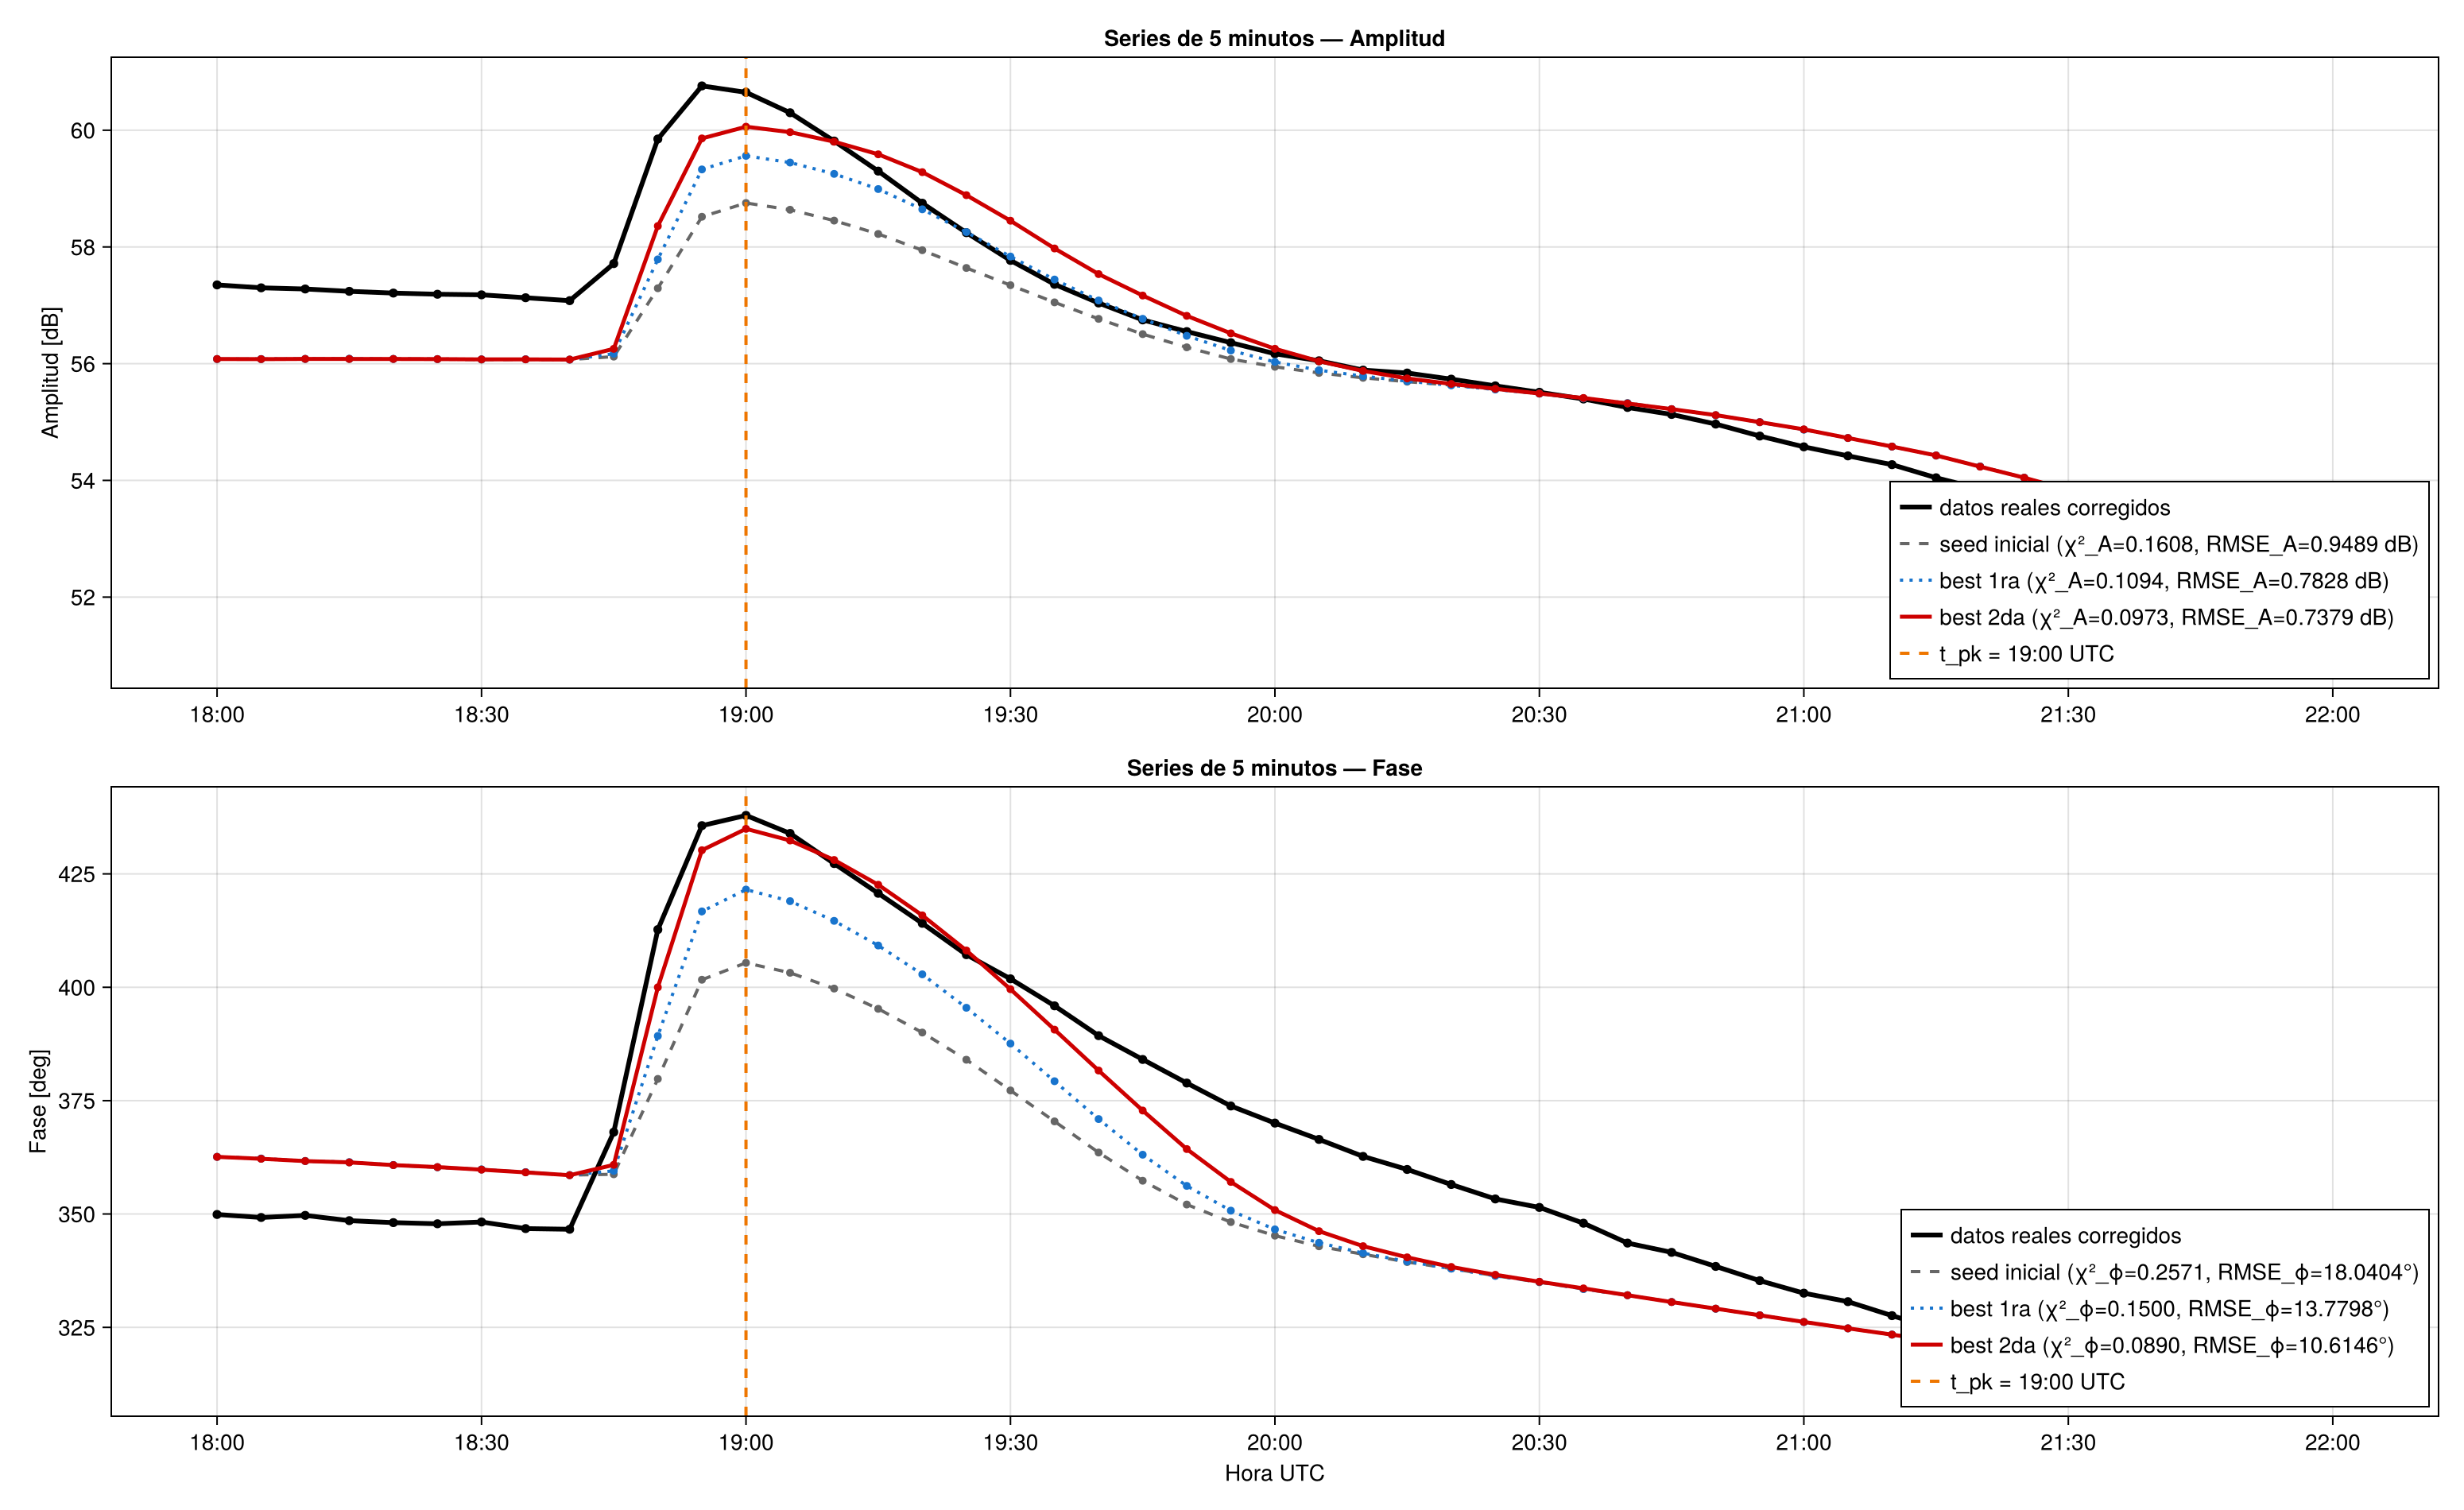

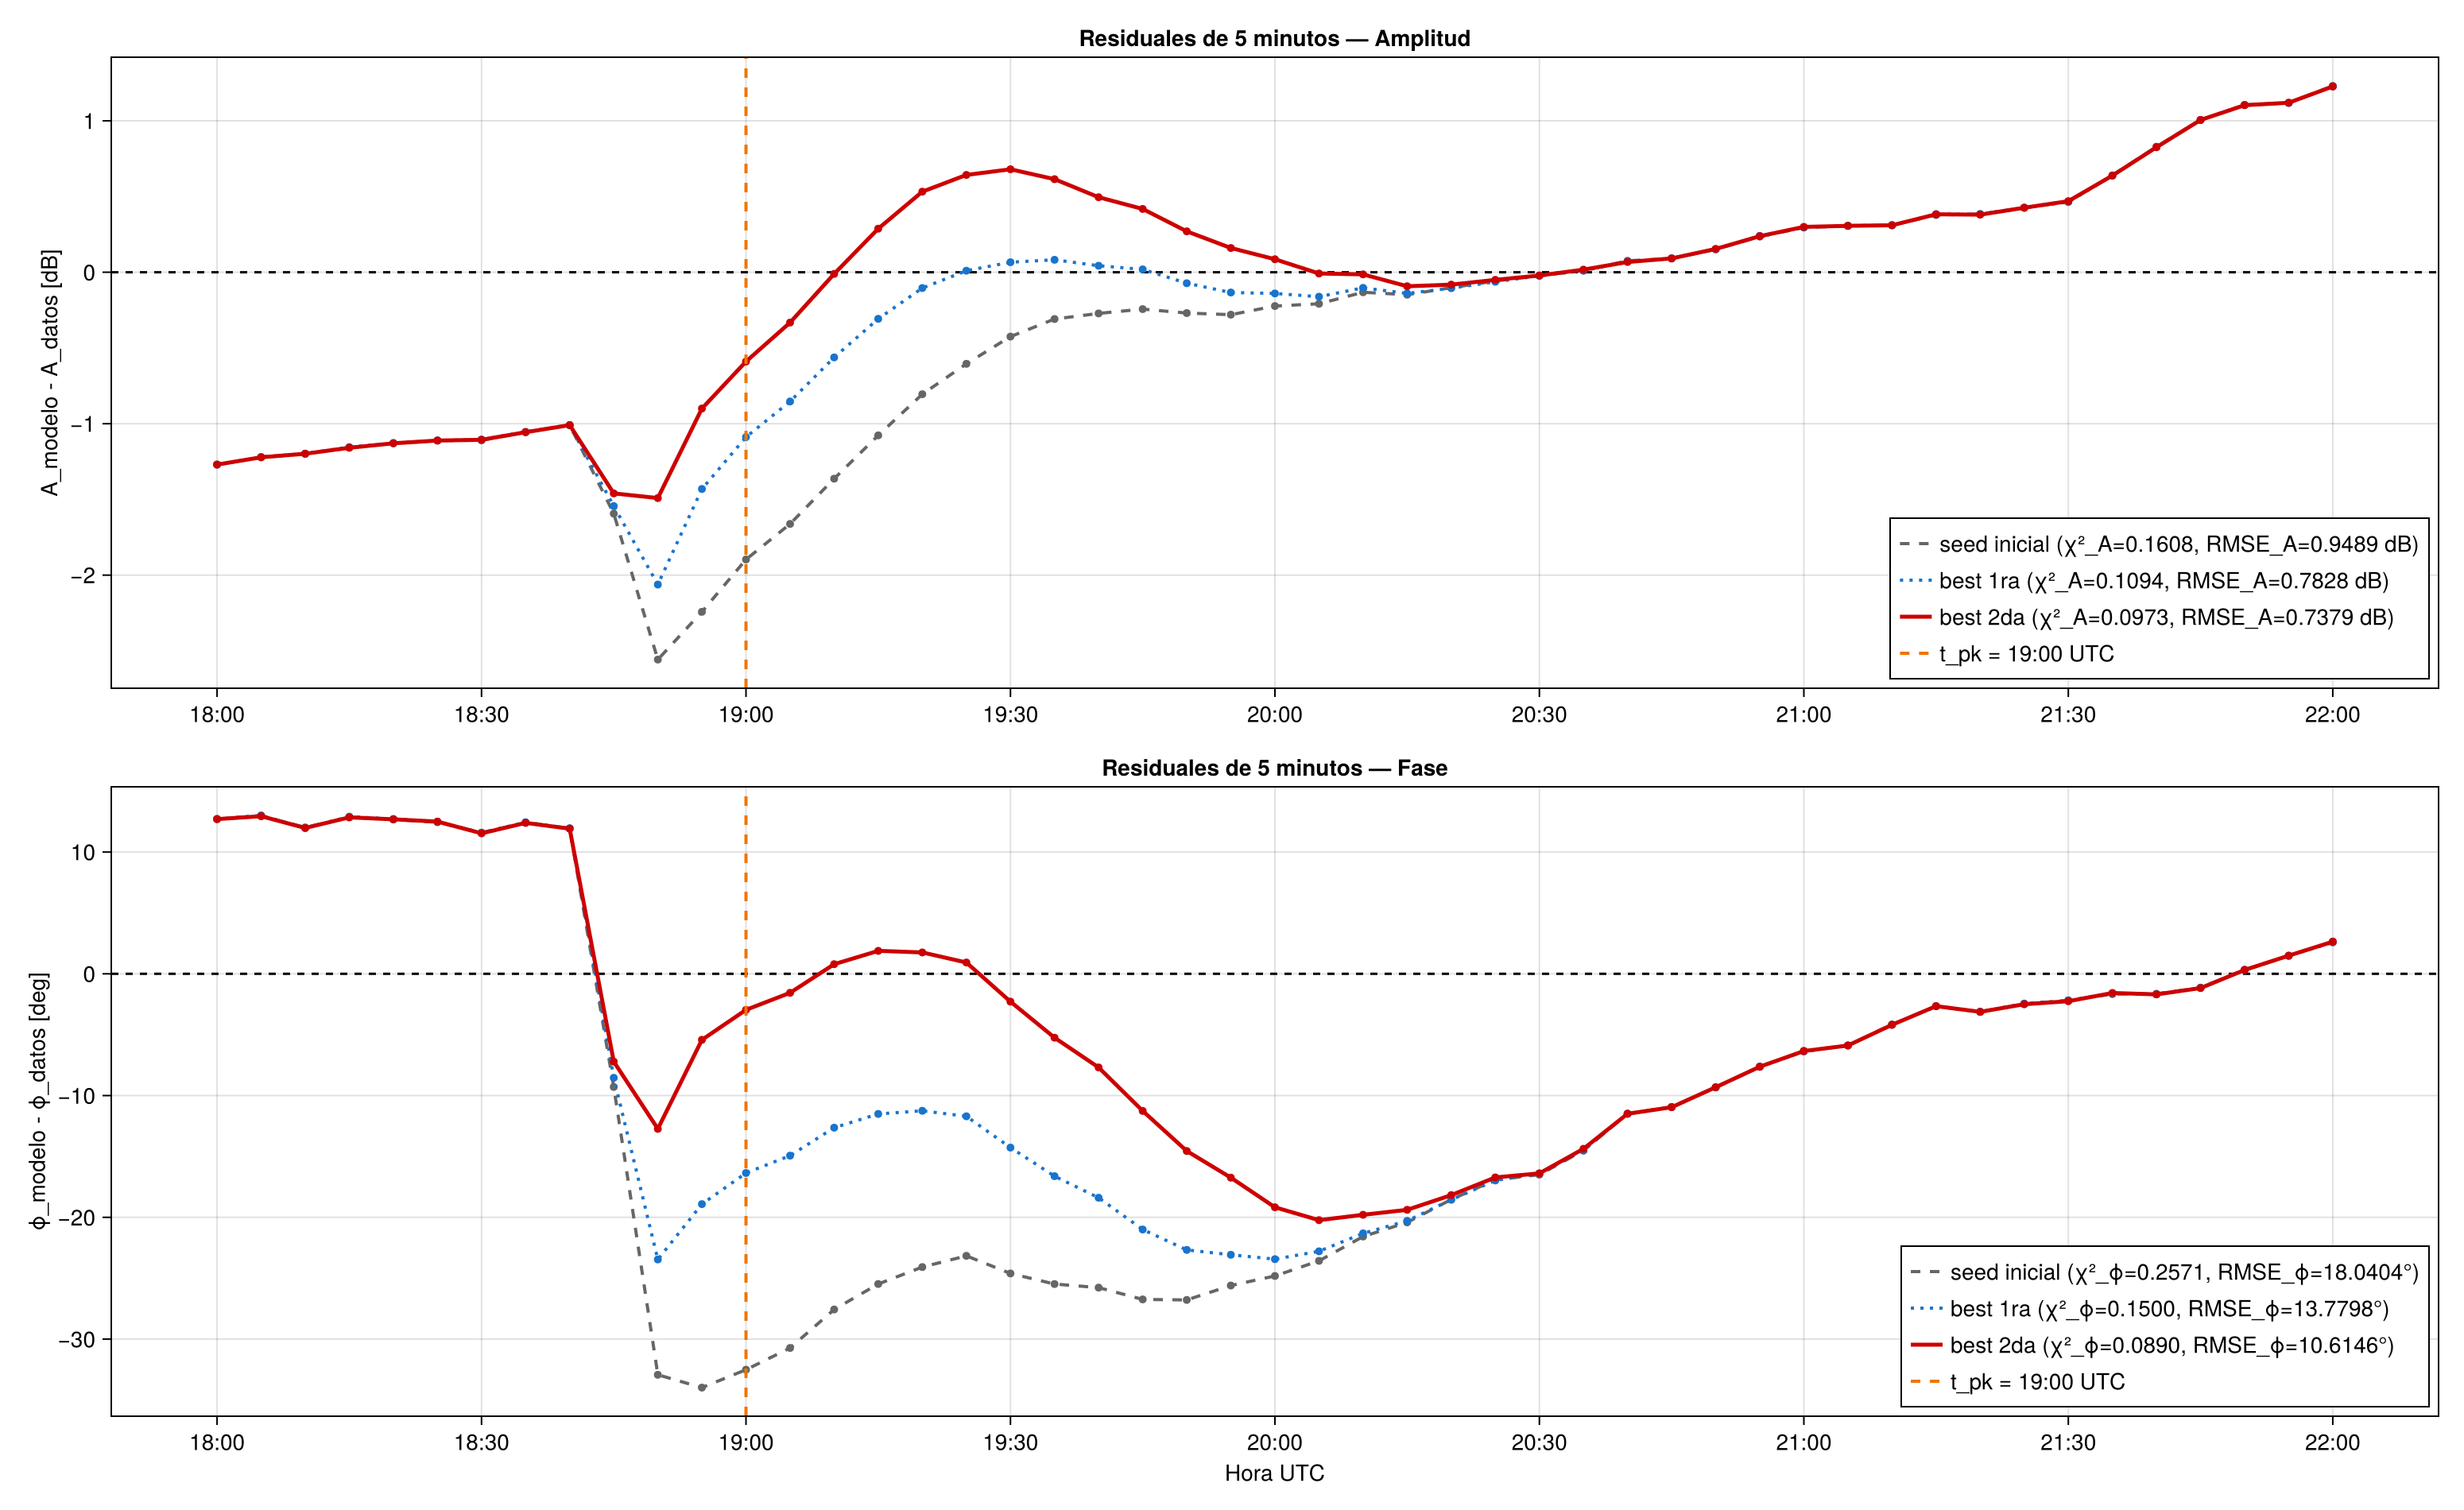

Figuras generadas:
  fig_ts  = series temporales de 5 minutos
  fig_res = residuales modelo - datos


In [18]:
using CairoMakie
using Dates
using Printf

# --------------------------------------------------------------------------------------------------
# Verificaciones
# --------------------------------------------------------------------------------------------------

required_vars = [
    :dt_5min,
    :t_min_5min,
    :A_target_5min,
    :phi_target_5min,
    :A_seed_5min,
    :phi_seed_5min,
    :A_best1_5min,
    :phi_best1_5min,
    :A_best2_5min,
    :phi_best2_5min,
    :res_A_seed_5min,
    :res_phi_seed_5min,
    :res_A_best1_5min,
    :res_phi_best1_5min,
    :res_A_best2_5min,
    :res_phi_best2_5min,
    :metrics_5min_df,
    :p_best2_full_5min,
]

missing_vars = [v for v in required_vars if !isdefined(Main, v)]

@assert isempty(missing_vars) "Faltan variables requeridas: $(join(string.(missing_vars), ", "))"

n5 = length(dt_5min)

@assert length(t_min_5min) == n5
@assert length(A_target_5min) == n5
@assert length(phi_target_5min) == n5
@assert length(A_seed_5min) == n5
@assert length(phi_seed_5min) == n5
@assert length(A_best1_5min) == n5
@assert length(phi_best1_5min) == n5
@assert length(A_best2_5min) == n5
@assert length(phi_best2_5min) == n5

# --------------------------------------------------------------------------------------------------
# Métricas para las leyendas
# --------------------------------------------------------------------------------------------------

i_seed = findfirst(==("seed inicial"), metrics_5min_df.caso)
i_best1 = findfirst(==("best 1ra"), metrics_5min_df.caso)
i_best2 = findfirst(==("best 2da"), metrics_5min_df.caso)

@assert i_seed !== nothing "No encontré 'seed inicial' en metrics_5min_df"
@assert i_best1 !== nothing "No encontré 'best 1ra' en metrics_5min_df"
@assert i_best2 !== nothing "No encontré 'best 2da' en metrics_5min_df"

m_seed = metrics_5min_df[i_seed, :]
m_best1 = metrics_5min_df[i_best1, :]
m_best2 = metrics_5min_df[i_best2, :]

label_seed_A = @sprintf(
    "seed inicial (χ²_A=%.4f, RMSE_A=%.4f dB)",
    m_seed.chi2_A,
    m_seed.RMSE_A_dB,
)

label_best1_A = @sprintf(
    "best 1ra (χ²_A=%.4f, RMSE_A=%.4f dB)",
    m_best1.chi2_A,
    m_best1.RMSE_A_dB,
)

label_best2_A = @sprintf(
    "best 2da (χ²_A=%.4f, RMSE_A=%.4f dB)",
    m_best2.chi2_A,
    m_best2.RMSE_A_dB,
)

label_seed_phi = @sprintf(
    "seed inicial (χ²_ϕ=%.4f, RMSE_ϕ=%.4f°)",
    m_seed.chi2_phi,
    m_seed.RMSE_phi_deg,
)

label_best1_phi = @sprintf(
    "best 1ra (χ²_ϕ=%.4f, RMSE_ϕ=%.4f°)",
    m_best1.chi2_phi,
    m_best1.RMSE_phi_deg,
)

label_best2_phi = @sprintf(
    "best 2da (χ²_ϕ=%.4f, RMSE_ϕ=%.4f°)",
    m_best2.chi2_phi,
    m_best2.RMSE_phi_deg,
)

# --------------------------------------------------------------------------------------------------
# Eje temporal y t_pk
# --------------------------------------------------------------------------------------------------

t_pk_sec = Float64(p_best2_full_5min[2])

# t_pk está medido desde 18:30 UTC, mientras que el eje empieza a las 18:00 UTC
t_pk_plot_min = 30.0 + t_pk_sec / 60.0

t_pk_datetime = first(dt_5min) + Minute(round(Int, t_pk_plot_min))
t_pk_label = "t_pk = $(Dates.format(t_pk_datetime, "HH:MM")) UTC"

tick_idx = collect(1:6:n5)

if last(tick_idx) != n5
    push!(tick_idx, n5)
end

xt = (
    t_min_5min[tick_idx],
    Dates.format.(dt_5min[tick_idx], "HH:MM"),
)

# Colores comunes para que línea y puntos coincidan
color_data = :black
color_seed = :gray40
color_best1 = :dodgerblue3
color_best2 = :red3
color_tpk = :darkorange2

# ================================================================================================
# FIGURA 1 — SERIES TEMPORALES
# ================================================================================================

fig_ts = Figure(size = (1550, 950))

axA = Axis(
    fig_ts[1, 1],
    title = "Series de 5 minutos — Amplitud",
    ylabel = "Amplitud [dB]",
    xticks = xt,
)

lines!(
    axA,
    t_min_5min,
    A_target_5min,
    color = color_data,
    linewidth = 3,
    label = "datos reales corregidos",
)

scatter!(
    axA,
    t_min_5min,
    A_target_5min,
    color = color_data,
    markersize = 8,
)

lines!(
    axA,
    t_min_5min,
    A_seed_5min,
    color = color_seed,
    linestyle = :dash,
    linewidth = 2,
    label = label_seed_A,
)

scatter!(
    axA,
    t_min_5min,
    A_seed_5min,
    color = color_seed,
    markersize = 7,
)

lines!(
    axA,
    t_min_5min,
    A_best1_5min,
    color = color_best1,
    linestyle = :dot,
    linewidth = 2,
    label = label_best1_A,
)

scatter!(
    axA,
    t_min_5min,
    A_best1_5min,
    color = color_best1,
    markersize = 7,
)

lines!(
    axA,
    t_min_5min,
    A_best2_5min,
    color = color_best2,
    linewidth = 2.5,
    label = label_best2_A,
)

scatter!(
    axA,
    t_min_5min,
    A_best2_5min,
    color = color_best2,
    markersize = 7,
)

vlines!(
    axA,
    [t_pk_plot_min],
    color = color_tpk,
    linestyle = :dash,
    linewidth = 2,
    label = t_pk_label,
)

axislegend(axA, position = :rb)

axPhi = Axis(
    fig_ts[2, 1],
    title = "Series de 5 minutos — Fase",
    xlabel = "Hora UTC",
    ylabel = "Fase [deg]",
    xticks = xt,
)

lines!(
    axPhi,
    t_min_5min,
    phi_target_5min,
    color = color_data,
    linewidth = 3,
    label = "datos reales corregidos",
)

scatter!(
    axPhi,
    t_min_5min,
    phi_target_5min,
    color = color_data,
    markersize = 8,
)

lines!(
    axPhi,
    t_min_5min,
    phi_seed_5min,
    color = color_seed,
    linestyle = :dash,
    linewidth = 2,
    label = label_seed_phi,
)

scatter!(
    axPhi,
    t_min_5min,
    phi_seed_5min,
    color = color_seed,
    markersize = 7,
)

lines!(
    axPhi,
    t_min_5min,
    phi_best1_5min,
    color = color_best1,
    linestyle = :dot,
    linewidth = 2,
    label = label_best1_phi,
)

scatter!(
    axPhi,
    t_min_5min,
    phi_best1_5min,
    color = color_best1,
    markersize = 7,
)

lines!(
    axPhi,
    t_min_5min,
    phi_best2_5min,
    color = color_best2,
    linewidth = 2.5,
    label = label_best2_phi,
)

scatter!(
    axPhi,
    t_min_5min,
    phi_best2_5min,
    color = color_best2,
    markersize = 7,
)

vlines!(
    axPhi,
    [t_pk_plot_min],
    color = color_tpk,
    linestyle = :dash,
    linewidth = 2,
    label = t_pk_label,
)

axislegend(axPhi, position = :rb)

linkxaxes!(axA, axPhi)

display(fig_ts)

# ================================================================================================
# FIGURA 2 — RESIDUALES
# ================================================================================================

fig_res = Figure(size = (1550, 950))

axRA = Axis(
    fig_res[1, 1],
    title = "Residuales de 5 minutos — Amplitud",
    ylabel = "A_modelo - A_datos [dB]",
    xticks = xt,
)

hlines!(
    axRA,
    [0.0],
    color = :black,
    linestyle = :dash,
    linewidth = 1.5,
)

lines!(
    axRA,
    t_min_5min,
    res_A_seed_5min,
    color = color_seed,
    linestyle = :dash,
    linewidth = 2,
    label = label_seed_A,
)

scatter!(
    axRA,
    t_min_5min,
    res_A_seed_5min,
    color = color_seed,
    markersize = 7,
)

lines!(
    axRA,
    t_min_5min,
    res_A_best1_5min,
    color = color_best1,
    linestyle = :dot,
    linewidth = 2,
    label = label_best1_A,
)

scatter!(
    axRA,
    t_min_5min,
    res_A_best1_5min,
    color = color_best1,
    markersize = 7,
)

lines!(
    axRA,
    t_min_5min,
    res_A_best2_5min,
    color = color_best2,
    linewidth = 2.5,
    label = label_best2_A,
)

scatter!(
    axRA,
    t_min_5min,
    res_A_best2_5min,
    color = color_best2,
    markersize = 7,
)

vlines!(
    axRA,
    [t_pk_plot_min],
    color = color_tpk,
    linestyle = :dash,
    linewidth = 2,
    label = t_pk_label,
)

axislegend(axRA, position = :rb)

axRPhi = Axis(
    fig_res[2, 1],
    title = "Residuales de 5 minutos — Fase",
    xlabel = "Hora UTC",
    ylabel = "ϕ_modelo - ϕ_datos [deg]",
    xticks = xt,
)

hlines!(
    axRPhi,
    [0.0],
    color = :black,
    linestyle = :dash,
    linewidth = 1.5,
)

lines!(
    axRPhi,
    t_min_5min,
    res_phi_seed_5min,
    color = color_seed,
    linestyle = :dash,
    linewidth = 2,
    label = label_seed_phi,
)

scatter!(
    axRPhi,
    t_min_5min,
    res_phi_seed_5min,
    color = color_seed,
    markersize = 7,
)

lines!(
    axRPhi,
    t_min_5min,
    res_phi_best1_5min,
    color = color_best1,
    linestyle = :dot,
    linewidth = 2,
    label = label_best1_phi,
)

scatter!(
    axRPhi,
    t_min_5min,
    res_phi_best1_5min,
    color = color_best1,
    markersize = 7,
)

lines!(
    axRPhi,
    t_min_5min,
    res_phi_best2_5min,
    color = color_best2,
    linewidth = 2.5,
    label = label_best2_phi,
)

scatter!(
    axRPhi,
    t_min_5min,
    res_phi_best2_5min,
    color = color_best2,
    markersize = 7,
)

vlines!(
    axRPhi,
    [t_pk_plot_min],
    color = color_tpk,
    linestyle = :dash,
    linewidth = 2,
    label = t_pk_label,
)

axislegend(axRPhi, position = :rb)

linkxaxes!(axRA, axRPhi)

display(fig_res)

println("Figuras generadas:")
println("  fig_ts  = series temporales de 5 minutos")
println("  fig_res = residuales modelo - datos")

Cargando comparación desde:
  /home/jp/basefolder_JP/series_5min_FIXED_TPK/series_5min_seed_oldASLSbest_whittakerbest_FIXED_TPK.h5
Verificación temporal correcta:
  N = 49
  máxima diferencia entre grillas = 0 s
  rango UTC = 18.0–22.0 h

Métricas contra los datos reales corregidos:


Row,metodo,chi2_A,chi2_phi,chi2_total,RMSE_A_dB,RMSE_phi_deg
,String,Float64,Float64,Float64,Float64,Float64
1,seed inicial,0.160803,0.25706,0.417863,0.948856,18.0404
2,PolyF3 best 2da,0.0972514,0.0889919,0.186243,0.737906,10.6146
3,ASLS viejo best 2da,0.0692188,0.236312,0.30553,0.622537,17.297
4,Whittaker nuevo best 2da,0.167012,0.114903,0.281915,0.967001,12.0613


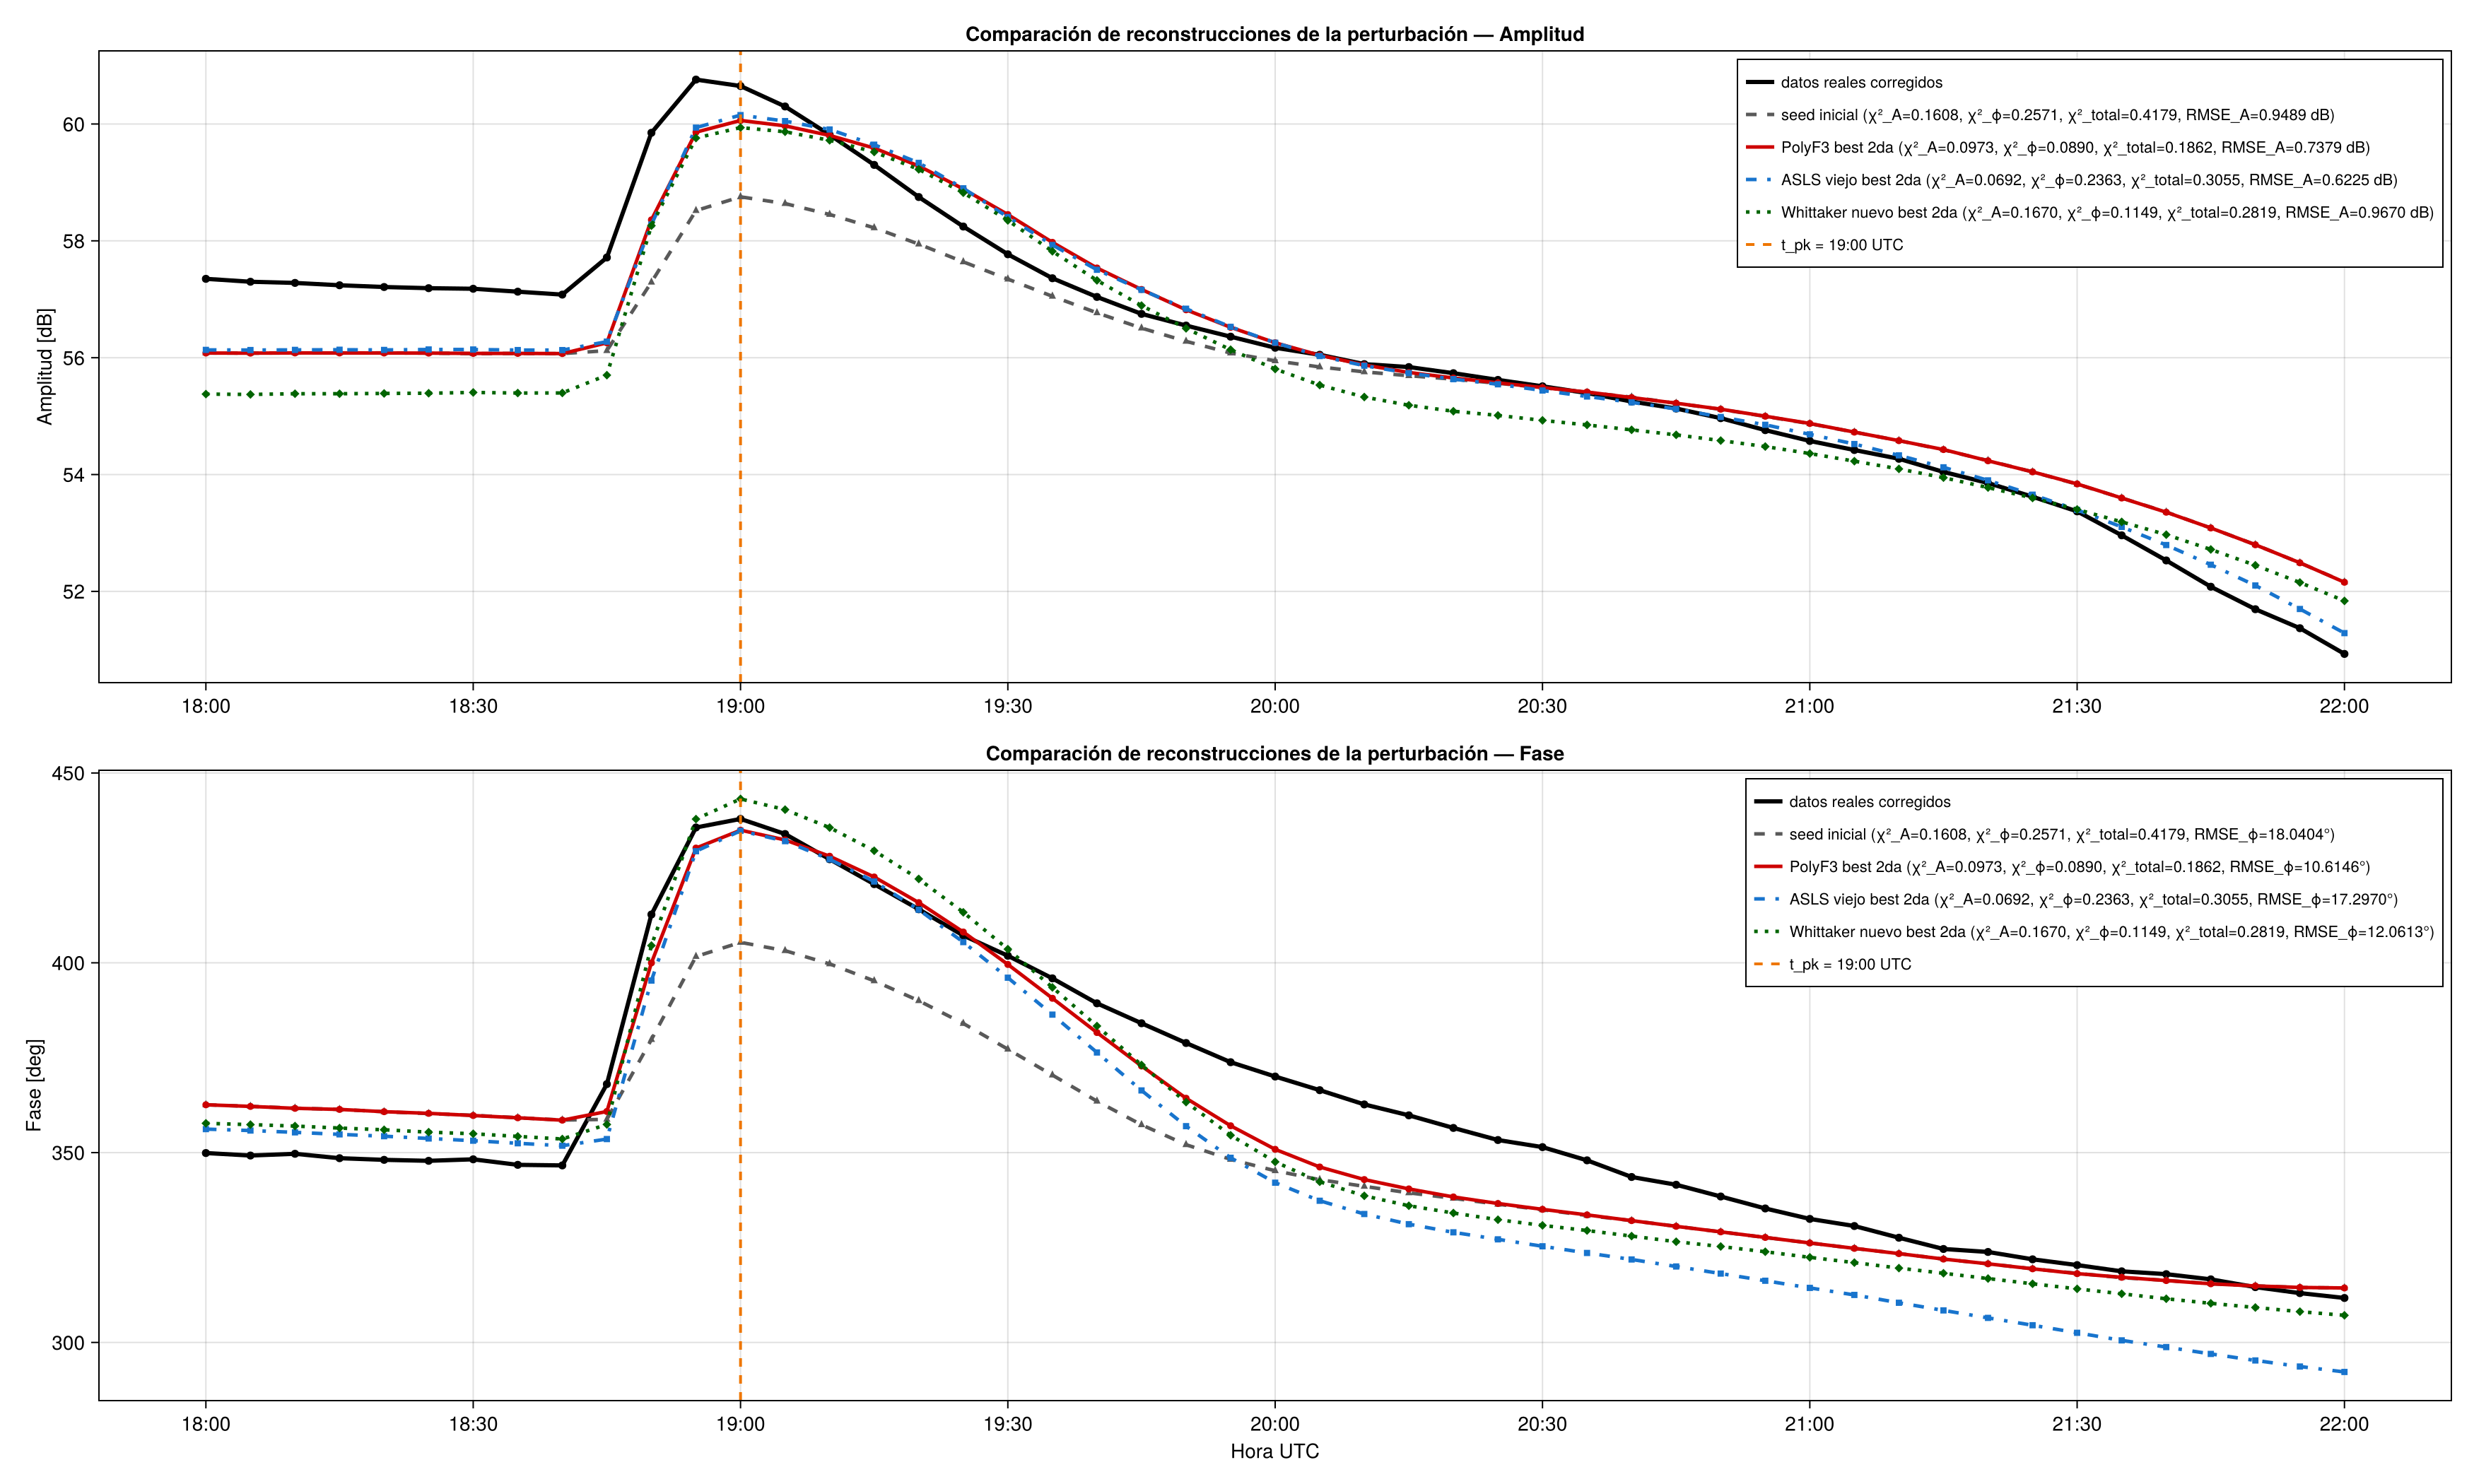

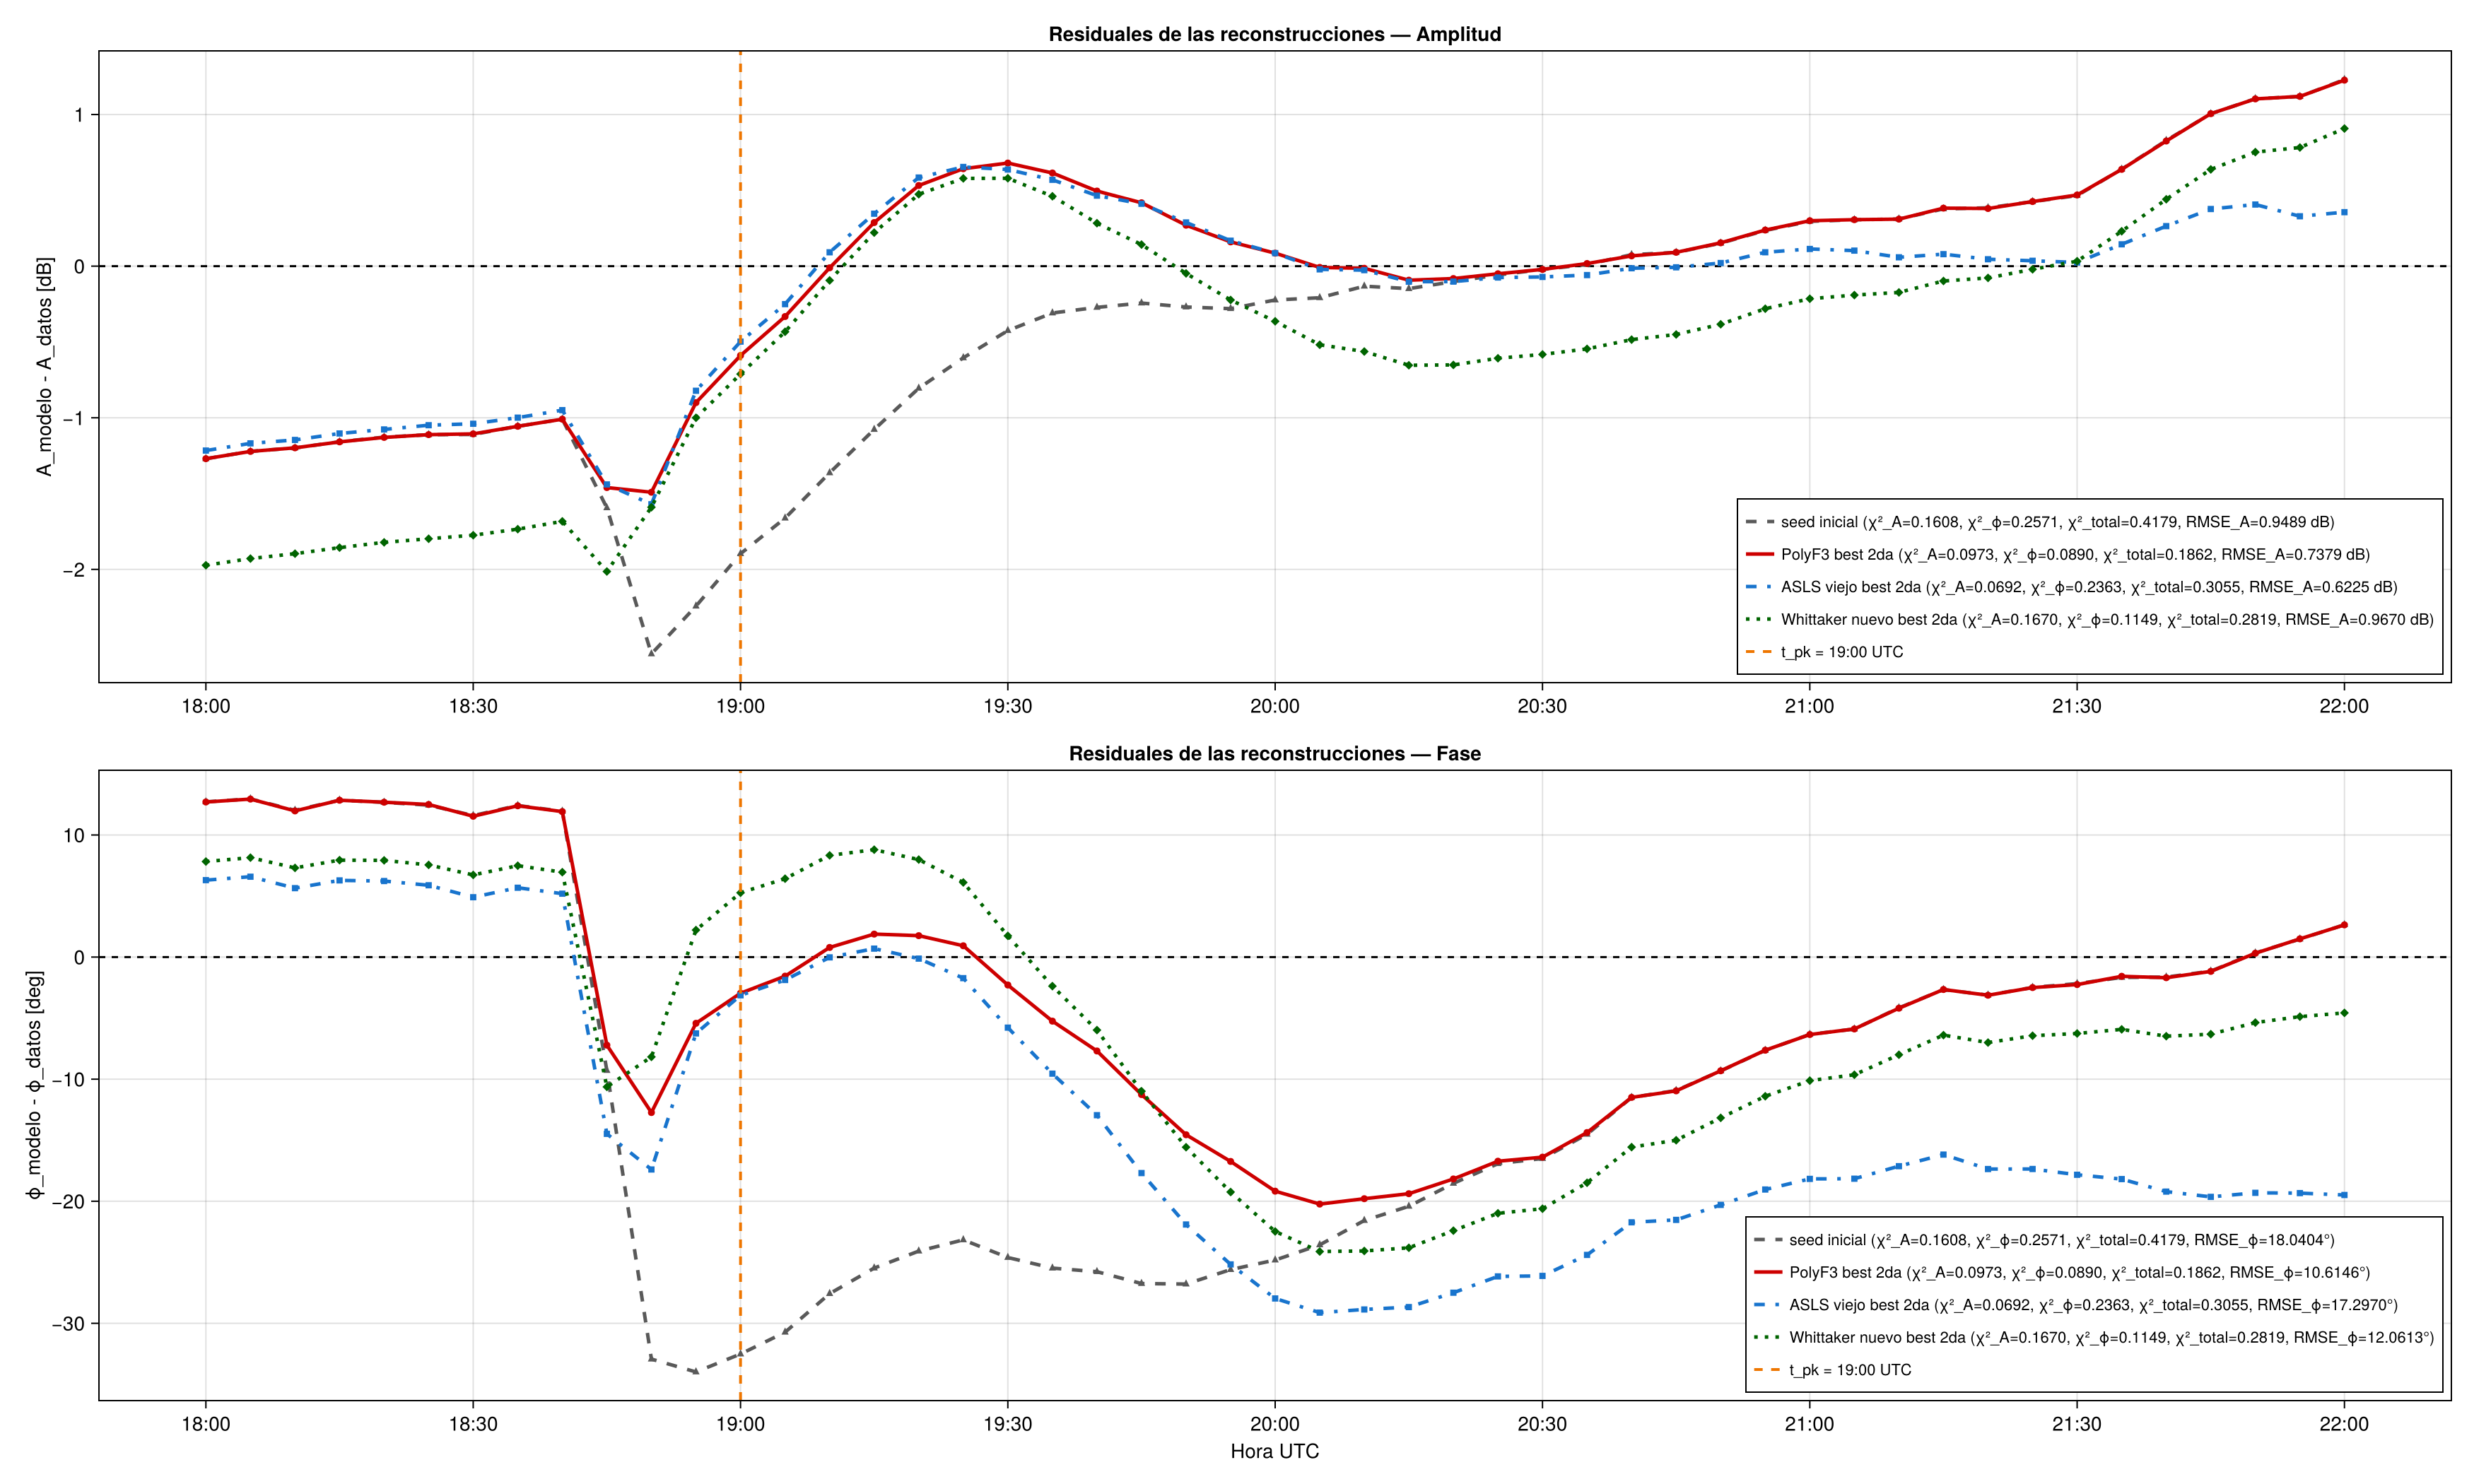


Variables principales generadas:
  metrics_background_comparison_5min
  fig_background_comparison_5min
  fig_background_residuals_5min


In [22]:
using HDF5
using DataFrames
using Statistics
using CairoMakie
using Printf
using Dates

# ================================================================================================
# Comparación a 5 minutos:
#   1. Seed inicial
#   2. PolyF3 — best segunda corrida
#   3. Background ASLS viejo — best segunda corrida
#   4. Background Whittaker nuevo — best segunda corrida
# ================================================================================================

@assert isdefined(Main, :timestamps_5min) "Falta timestamps_5min."
@assert isdefined(Main, :A_target_5min) "Falta A_target_5min."
@assert isdefined(Main, :phi_target_5min) "Falta phi_target_5min."
@assert isdefined(Main, :A_seed_5min) "Falta A_seed_5min."
@assert isdefined(Main, :phi_seed_5min) "Falta phi_seed_5min."
@assert isdefined(Main, :A_best2_5min) "Falta A_best2_5min."
@assert isdefined(Main, :phi_best2_5min) "Falta phi_best2_5min."

# --------------------------------------------------------------------------------------------------
# Archivo que contiene las series ASLS viejo y Whittaker nuevo
# --------------------------------------------------------------------------------------------------

comparison_h5 =
    "/home/jp/basefolder_JP/series_5min_FIXED_TPK/series_5min_seed_oldASLSbest_whittakerbest_FIXED_TPK.h5"

if !isfile(comparison_h5)
    comparison_h5 = joinpath(
        pwd(),
        "series_5min_seed_oldASLSbest_whittakerbest_FIXED_TPK.h5",
    )
end

@assert isfile(comparison_h5) "No encuentro el archivo HDF5: $(comparison_h5)"

println("Cargando comparación desde:")
println("  ", comparison_h5)

# --------------------------------------------------------------------------------------------------
# Cargar grilla y series anteriores
# --------------------------------------------------------------------------------------------------

t_hours_comparison = Float64.(vec(
    HDF5.h5read(comparison_h5, "time/t_hours"),
))

timestamps_comparison = Float64.(vec(
    HDF5.h5read(comparison_h5, "time/timestamps_unix"),
))

A_oldASLS_best2_5min = Float64.(vec(
    HDF5.h5read(comparison_h5, "oldASLS_best2/A_model"),
))

phi_oldASLS_best2_5min = Float64.(vec(
    HDF5.h5read(comparison_h5, "oldASLS_best2/phi_model"),
))

A_whittaker_best2_5min = Float64.(vec(
    HDF5.h5read(comparison_h5, "whittaker_best2/A_model"),
))

phi_whittaker_best2_5min = Float64.(vec(
    HDF5.h5read(comparison_h5, "whittaker_best2/phi_model"),
))

A_seed_comparison_5min = Float64.(vec(A_seed_5min))
phi_seed_comparison_5min = Float64.(vec(phi_seed_5min))

A_polyF3_best2_5min = Float64.(vec(A_best2_5min))
phi_polyF3_best2_5min = Float64.(vec(phi_best2_5min))

A_data_comparison_5min = Float64.(vec(A_target_5min))
phi_data_comparison_5min = Float64.(vec(phi_target_5min))

# --------------------------------------------------------------------------------------------------
# Verificar que todas las series usan la misma grilla temporal
# --------------------------------------------------------------------------------------------------

timestamps_poly_int = round.(Int64, vec(timestamps_5min))
timestamps_comparison_int = round.(Int64, timestamps_comparison)

n_comparison = length(timestamps_poly_int)

@assert length(timestamps_comparison_int) == n_comparison
@assert length(t_hours_comparison) == n_comparison

max_time_difference_s = maximum(
    abs.(timestamps_poly_int .- timestamps_comparison_int),
)

@assert max_time_difference_s <= 1 """
Las grillas temporales no coinciden.
Máxima diferencia encontrada: $(max_time_difference_s) s
"""

@assert length(A_data_comparison_5min) == n_comparison
@assert length(phi_data_comparison_5min) == n_comparison

@assert length(A_seed_comparison_5min) == n_comparison
@assert length(phi_seed_comparison_5min) == n_comparison

@assert length(A_polyF3_best2_5min) == n_comparison
@assert length(phi_polyF3_best2_5min) == n_comparison

@assert length(A_oldASLS_best2_5min) == n_comparison
@assert length(phi_oldASLS_best2_5min) == n_comparison

@assert length(A_whittaker_best2_5min) == n_comparison
@assert length(phi_whittaker_best2_5min) == n_comparison

println("Verificación temporal correcta:")
println("  N = ", n_comparison)
println("  máxima diferencia entre grillas = ", max_time_difference_s, " s")
println("  rango UTC = ", first(t_hours_comparison), "–", last(t_hours_comparison), " h")

# --------------------------------------------------------------------------------------------------
# Series a comparar
# --------------------------------------------------------------------------------------------------

method_names_5min = [
    "seed inicial",
    "PolyF3 best 2da",
    "ASLS viejo best 2da",
    "Whittaker nuevo best 2da",
]

A_models_comparison_5min = [
    A_seed_comparison_5min,
    A_polyF3_best2_5min,
    A_oldASLS_best2_5min,
    A_whittaker_best2_5min,
]

phi_models_comparison_5min = [
    phi_seed_comparison_5min,
    phi_polyF3_best2_5min,
    phi_oldASLS_best2_5min,
    phi_whittaker_best2_5min,
]

# --------------------------------------------------------------------------------------------------
# Métricas homogéneas contra los datos reales corregidos
# --------------------------------------------------------------------------------------------------

den_A_comparison = sum(
    (A_data_comparison_5min .- mean(A_data_comparison_5min)) .^ 2,
)

den_phi_comparison = sum(
    (phi_data_comparison_5min .- mean(phi_data_comparison_5min)) .^ 2,
)

@assert den_A_comparison > 0.0
@assert den_phi_comparison > 0.0

n_methods = length(method_names_5min)

chi2_A_comparison = zeros(Float64, n_methods)
chi2_phi_comparison = zeros(Float64, n_methods)
chi2_total_comparison = zeros(Float64, n_methods)
RMSE_A_comparison = zeros(Float64, n_methods)
RMSE_phi_comparison = zeros(Float64, n_methods)

for i in eachindex(method_names_5min)
    dA = A_models_comparison_5min[i] .- A_data_comparison_5min
    dphi = phi_models_comparison_5min[i] .- phi_data_comparison_5min

    chi2_A_comparison[i] = sum(dA .^ 2) / den_A_comparison
    chi2_phi_comparison[i] = sum(dphi .^ 2) / den_phi_comparison
    chi2_total_comparison[i] =
        chi2_A_comparison[i] + chi2_phi_comparison[i]

    RMSE_A_comparison[i] = sqrt(mean(dA .^ 2))
    RMSE_phi_comparison[i] = sqrt(mean(dphi .^ 2))
end

metrics_background_comparison_5min = DataFrame(
    metodo = method_names_5min,
    chi2_A = chi2_A_comparison,
    chi2_phi = chi2_phi_comparison,
    chi2_total = chi2_total_comparison,
    RMSE_A_dB = RMSE_A_comparison,
    RMSE_phi_deg = RMSE_phi_comparison,
)

println("\nMétricas contra los datos reales corregidos:")
display(metrics_background_comparison_5min)

# --------------------------------------------------------------------------------------------------
# Leyendas
#
# Cada reconstrucción contiene:
#   χ²_A, χ²_ϕ, χ²_total y el RMSE correspondiente al panel
# --------------------------------------------------------------------------------------------------

labels_A_comparison = [
    @sprintf(
        "%s (χ²_A=%.4f, χ²_ϕ=%.4f, χ²_total=%.4f, RMSE_A=%.4f dB)",
        method_names_5min[i],
        chi2_A_comparison[i],
        chi2_phi_comparison[i],
        chi2_total_comparison[i],
        RMSE_A_comparison[i],
    )
    for i in eachindex(method_names_5min)
]

labels_phi_comparison = [
    @sprintf(
        "%s (χ²_A=%.4f, χ²_ϕ=%.4f, χ²_total=%.4f, RMSE_ϕ=%.4f°)",
        method_names_5min[i],
        chi2_A_comparison[i],
        chi2_phi_comparison[i],
        chi2_total_comparison[i],
        RMSE_phi_comparison[i],
    )
    for i in eachindex(method_names_5min)
]

# --------------------------------------------------------------------------------------------------
# Residuales: modelo - datos
# --------------------------------------------------------------------------------------------------

res_A_models_comparison_5min = [
    A_models_comparison_5min[i] .- A_data_comparison_5min
    for i in eachindex(method_names_5min)
]

res_phi_models_comparison_5min = [
    phi_models_comparison_5min[i] .- phi_data_comparison_5min
    for i in eachindex(method_names_5min)
]

res_A_seed_comparison_5min = res_A_models_comparison_5min[1]
res_A_polyF3_best2_5min = res_A_models_comparison_5min[2]
res_A_oldASLS_best2_5min = res_A_models_comparison_5min[3]
res_A_whittaker_best2_5min = res_A_models_comparison_5min[4]

res_phi_seed_comparison_5min = res_phi_models_comparison_5min[1]
res_phi_polyF3_best2_5min = res_phi_models_comparison_5min[2]
res_phi_oldASLS_best2_5min = res_phi_models_comparison_5min[3]
res_phi_whittaker_best2_5min = res_phi_models_comparison_5min[4]

# --------------------------------------------------------------------------------------------------
# Configuración gráfica
# --------------------------------------------------------------------------------------------------

colors_comparison = [
    :gray35,
    :red3,
    :dodgerblue3,
    :darkgreen,
]

linestyles_comparison = [
    :dash,
    :solid,
    :dashdot,
    :dot,
]

markers_comparison = [
    :utriangle,
    :circle,
    :rect,
    :diamond,
]

tick_values = collect(18.0:0.5:22.0)

tick_datetimes = collect(
    DateTime(2008, 3, 25, 18, 0, 0):
    Minute(30):
    DateTime(2008, 3, 25, 22, 0, 0)
)

xticks_comparison = (
    tick_values,
    Dates.format.(tick_datetimes, "HH:MM"),
)

t_pk_hours = 19.0
t_pk_label_comparison = "t_pk = 19:00 UTC"

# ================================================================================================
# FIGURA 1 — SERIES TEMPORALES
# ================================================================================================

fig_background_comparison_5min = Figure(size = (1750, 1050))

ax_A_background_comparison = Axis(
    fig_background_comparison_5min[1, 1],
    title = "Comparación de reconstrucciones de la perturbación — Amplitud",
    ylabel = "Amplitud [dB]",
    xticks = xticks_comparison,
)

lines!(
    ax_A_background_comparison,
    t_hours_comparison,
    A_data_comparison_5min,
    color = :black,
    linewidth = 3,
    label = "datos reales corregidos",
)

scatter!(
    ax_A_background_comparison,
    t_hours_comparison,
    A_data_comparison_5min,
    color = :black,
    markersize = 8,
)

for i in eachindex(method_names_5min)
    lines!(
        ax_A_background_comparison,
        t_hours_comparison,
        A_models_comparison_5min[i],
        color = colors_comparison[i],
        linestyle = linestyles_comparison[i],
        linewidth = 2.5,
        label = labels_A_comparison[i],
    )

    scatter!(
        ax_A_background_comparison,
        t_hours_comparison,
        A_models_comparison_5min[i],
        color = colors_comparison[i],
        marker = markers_comparison[i],
        markersize = 7,
    )
end

vlines!(
    ax_A_background_comparison,
    [t_pk_hours],
    color = :darkorange2,
    linestyle = :dash,
    linewidth = 2,
    label = t_pk_label_comparison,
)

axislegend(
    ax_A_background_comparison,
    position = :rt,
    labelsize = 11,
)

ax_phi_background_comparison = Axis(
    fig_background_comparison_5min[2, 1],
    title = "Comparación de reconstrucciones de la perturbación — Fase",
    xlabel = "Hora UTC",
    ylabel = "Fase [deg]",
    xticks = xticks_comparison,
)

lines!(
    ax_phi_background_comparison,
    t_hours_comparison,
    phi_data_comparison_5min,
    color = :black,
    linewidth = 3,
    label = "datos reales corregidos",
)

scatter!(
    ax_phi_background_comparison,
    t_hours_comparison,
    phi_data_comparison_5min,
    color = :black,
    markersize = 8,
)

for i in eachindex(method_names_5min)
    lines!(
        ax_phi_background_comparison,
        t_hours_comparison,
        phi_models_comparison_5min[i],
        color = colors_comparison[i],
        linestyle = linestyles_comparison[i],
        linewidth = 2.5,
        label = labels_phi_comparison[i],
    )

    scatter!(
        ax_phi_background_comparison,
        t_hours_comparison,
        phi_models_comparison_5min[i],
        color = colors_comparison[i],
        marker = markers_comparison[i],
        markersize = 7,
    )
end

vlines!(
    ax_phi_background_comparison,
    [t_pk_hours],
    color = :darkorange2,
    linestyle = :dash,
    linewidth = 2,
    label = t_pk_label_comparison,
)

axislegend(
    ax_phi_background_comparison,
    position = :rt,
    labelsize = 11,
)

linkxaxes!(
    ax_A_background_comparison,
    ax_phi_background_comparison,
)

xlims!(ax_A_background_comparison, 18.0, 22.0)

display(fig_background_comparison_5min)

# ================================================================================================
# FIGURA 2 — RESIDUALES
# ================================================================================================

fig_background_residuals_5min = Figure(size = (1750, 1050))

ax_res_A_background_comparison = Axis(
    fig_background_residuals_5min[1, 1],
    title = "Residuales de las reconstrucciones — Amplitud",
    ylabel = "A_modelo - A_datos [dB]",
    xticks = xticks_comparison,
)

hlines!(
    ax_res_A_background_comparison,
    [0.0],
    color = :black,
    linestyle = :dash,
    linewidth = 1.5,
)

for i in eachindex(method_names_5min)
    lines!(
        ax_res_A_background_comparison,
        t_hours_comparison,
        res_A_models_comparison_5min[i],
        color = colors_comparison[i],
        linestyle = linestyles_comparison[i],
        linewidth = 2.5,
        label = labels_A_comparison[i],
    )

    scatter!(
        ax_res_A_background_comparison,
        t_hours_comparison,
        res_A_models_comparison_5min[i],
        color = colors_comparison[i],
        marker = markers_comparison[i],
        markersize = 7,
    )
end

vlines!(
    ax_res_A_background_comparison,
    [t_pk_hours],
    color = :darkorange2,
    linestyle = :dash,
    linewidth = 2,
    label = t_pk_label_comparison,
)

axislegend(
    ax_res_A_background_comparison,
    position = :rb,
    labelsize = 11,
)

ax_res_phi_background_comparison = Axis(
    fig_background_residuals_5min[2, 1],
    title = "Residuales de las reconstrucciones — Fase",
    xlabel = "Hora UTC",
    ylabel = "ϕ_modelo - ϕ_datos [deg]",
    xticks = xticks_comparison,
)

hlines!(
    ax_res_phi_background_comparison,
    [0.0],
    color = :black,
    linestyle = :dash,
    linewidth = 1.5,
)

for i in eachindex(method_names_5min)
    lines!(
        ax_res_phi_background_comparison,
        t_hours_comparison,
        res_phi_models_comparison_5min[i],
        color = colors_comparison[i],
        linestyle = linestyles_comparison[i],
        linewidth = 2.5,
        label = labels_phi_comparison[i],
    )

    scatter!(
        ax_res_phi_background_comparison,
        t_hours_comparison,
        res_phi_models_comparison_5min[i],
        color = colors_comparison[i],
        marker = markers_comparison[i],
        markersize = 7,
    )
end

vlines!(
    ax_res_phi_background_comparison,
    [t_pk_hours],
    color = :darkorange2,
    linestyle = :dash,
    linewidth = 2,
    label = t_pk_label_comparison,
)

axislegend(
    ax_res_phi_background_comparison,
    position = :rb,
    labelsize = 11,
)

linkxaxes!(
    ax_res_A_background_comparison,
    ax_res_phi_background_comparison,
)

xlims!(ax_res_A_background_comparison, 18.0, 22.0)

display(fig_background_residuals_5min)

println("\nVariables principales generadas:")
println("  metrics_background_comparison_5min")
println("  fig_background_comparison_5min")
println("  fig_background_residuals_5min")